# 🎓 ĐỒ ÁN PYTHON
## HỆ THỐNG GIAO DỊCH TỰ ĐỘNG ỨNG DỤNG HỌC TĂNG CƯỜNG & NLP  
### Deep Reinforcement Learning với Attention và Chiến lược Phân bổ Tỷ trọng Mục tiêu

---

## 👥 Thông tin sinh viên thực hiện
- **Đặng Quốc Hiệp** – MSSV: 23110151  
- **Phạm Chí Hiếu** – MSSV: 23110083  
- **Võ Lê Thế Bảo** – MSSV: 23110005  
- **Nguyễn Thanh Hậu** – MSSV: 23110149  

---

## 📖 TÓM TẮT (ABSTRACT)

Đề tài này tập trung nghiên cứu và xây dựng một **hệ thống giao dịch chứng khoán tự động** dựa trên **Học tăng cường sâu (Deep Reinforcement Learning)**, được thiết kế chuyên biệt cho thị trường chứng khoán Việt Nam (cổ phiếu nghiên cứu: **HPG**).

Khác với các hệ thống giao dịch truyền thống vốn tối ưu lợi nhuận tuyệt đối hoặc đưa ra tín hiệu mua/bán rời rạc, hệ thống đề xuất trong đề tài này hướng tới mục tiêu **tối ưu hiệu quả điều chỉnh theo rủi ro (Risk-adjusted Performance)** thông qua cơ chế **Phân bổ tỷ trọng danh mục liên tục (Target Allocation)**.

Hệ thống kết hợp ba thành phần cốt lõi:

1. **Học tăng cường sâu (Reinforcement Learning):**  
   Sử dụng thuật toán **Proximal Policy Optimization (PPO)** để học chính sách phân bổ vốn tối ưu trong không gian hành động liên tục.

2. **Cơ chế Attention cho chuỗi thời gian:**  
   Áp dụng **Self-Attention** nhằm giúp mô hình tập trung vào các phiên giao dịch có thông tin quan trọng trong cửa sổ thời gian 30 ngày, từ đó giảm nhiễu và cải thiện khả năng trích xuất đặc trưng.

3. **Giải thích quyết định (Explainable AI – XAI):**  
   Tích hợp mô hình ngôn ngữ lớn **Google Gemini** để diễn giải các quyết định phân bổ tỷ trọng của AI thành báo cáo ngôn ngữ tự nhiên, giúp tăng tính minh bạch và khả năng hiểu của con người.

Thông qua quy trình **Walk-Forward Validation** từ năm 2020 đến 2025, hệ thống cho thấy khả năng **kiểm soát drawdown vượt trội**, đồng thời đạt các chỉ số Sharpe và Calmar cao hơn chiến lược Buy-and-Hold, đặc biệt trong các giai đoạn thị trường suy thoái mạnh.

---


## **I. TỔNG QUAN HỆ THỐNG (SYSTEM OVERVIEW)**

Dự án này tập trung xây dựng một **thực thể giao dịch trí tuệ nhân tạo (AI Trader)** có khả năng **tự vận hành hoàn toàn**, phân tích đa chiều dữ liệu thị trường và đưa ra **quyết định phân bổ tài sản tối ưu (Asset Allocation)** trên thị trường chứng khoán Việt Nam.

Khác với các hệ thống giao dịch truyền thống vốn chỉ tập trung vào **dự báo giá** hoặc **tín hiệu mua/bán rời rạc**, hệ thống trong đề tài này được thiết kế theo tư duy **quản trị danh mục đầu tư chuyên nghiệp**, trong đó AI đóng vai trò như một **nhà quản lý quỹ định lượng (Quant Portfolio Manager)**.

Hệ thống kết hợp nhiều công nghệ tiên tiến gồm:
- Học tăng cường sâu (Deep Reinforcement Learning),
- Cơ chế chú ý (Self-Attention) cho chuỗi thời gian,
- Phân tích dữ liệu đa phương thức (giá + tin tức),
- Và lớp giải thích quyết định bằng mô hình ngôn ngữ lớn (Explainable AI).

Mục tiêu cuối cùng của hệ thống không chỉ là tối đa hóa lợi nhuận, mà là **tối ưu hiệu quả điều chỉnh theo rủi ro (Risk-adjusted Performance)** trong điều kiện thị trường biến động và nhiều nhiễu.

---

### **1.1. Mục tiêu và Triết lý Đầu tư**

Hệ thống được thiết kế nhằm giải quyết hai hạn chế lớn của nhà đầu tư cá nhân:

1. **Rào cản tâm lý trong giao dịch**
   - Sợ thua lỗ, FOMO, giữ lệnh thua quá lâu hoặc chốt lời quá sớm.
2. **Giới hạn trong khả năng xử lý dữ liệu lớn và phức tạp**
   - Không thể đồng thời phân tích hàng loạt chỉ báo kỹ thuật, dữ liệu lịch sử dài hạn và tin tức thị trường.

Từ đó, hệ thống được xây dựng dựa trên các nguyên tắc cốt lõi sau:

- **Tự động hóa hoàn toàn:**  
  Toàn bộ quy trình từ thu thập dữ liệu, tiền xử lý, trích xuất đặc trưng, huấn luyện mô hình, cho đến đưa ra quyết định giao dịch đều được tự động hóa, không có sự can thiệp chủ quan của con người.

- **Kỷ luật rủi ro:**  
  Hệ thống ưu tiên bảo toàn vốn thông qua:
  - Reward shaping hướng rủi ro,
  - Phạt mạnh drawdown lớn,
  - Cho phép AI chủ động đứng ngoài thị trường khi điều kiện không thuận lợi.

- **Tối ưu dài hạn:**  
  Agent không tối ưu lợi nhuận ngắn hạn từng phiên, mà học cách tối đa hóa giá trị danh mục trong dài hạn thông qua chuỗi quyết định liên tiếp.

---

### **1.2. Các Trụ cột Công nghệ Cốt lõi**

Hệ thống được xây dựng dựa trên bốn trụ cột công nghệ chính, có mối liên kết chặt chẽ với nhau.

---

#### **A. Lõi Trí tuệ: PPO kết hợp Self-Attention**

- **Proximal Policy Optimization (PPO):**  
  PPO là một thuật toán học tăng cường hiện đại, được lựa chọn nhờ:
  - Độ ổn định cao trong quá trình huấn luyện,
  - Khả năng xử lý **không gian hành động liên tục**,
  - Phù hợp với các bài toán tài chính có phân phối phần thưởng nhiều nhiễu.

  Trong hệ thống này, PPO học trực tiếp **chính sách phân bổ tỷ trọng danh mục**, thay vì dự đoán giá.

- **Self-Attention Mechanism:**  
  Lớp Attention được tích hợp để xử lý chuỗi dữ liệu thời gian (30 phiên gần nhất), cho phép mô hình:
  - Tự động tập trung vào các phiên giao dịch có thông tin quan trọng,
  - Giảm ảnh hưởng của nhiễu ngẫu nhiên,
  - Nhận diện các giai đoạn thị trường có regime rõ ràng (Trending / Sideways).

  Cơ chế này giúp mô hình học hiệu quả hơn so với các kiến trúc chỉ dựa trên mạng MLP truyền thống.

---

#### **B. Chiến lược Phân bổ vốn: Target Allocation**

Thay vì phương pháp mua/bán nhị phân (Buy/Sell), hệ thống áp dụng chiến lược **Target Allocation**, một tiêu chuẩn phổ biến trong quản lý quỹ định lượng.

- **Định nghĩa hành động:**  
  Hành động của AI tại thời điểm \(t\) là:
  \[
  a_t \in [0, 1]
  \]
  trong đó \(a_t\) đại diện cho **tỷ trọng vốn mục tiêu đầu tư vào cổ phiếu**.

- **Ý nghĩa thực tiễn:**
  - \(a_t = 0.0\): Thoát hoàn toàn khỏi thị trường (Full Cash).
  - \(a_t = 0.5\): Danh mục cân bằng.
  - \(a_t = 1.0\): Giải ngân toàn bộ vốn (Full Stock).

- **Ưu điểm:**
  - Cho phép tái cân bằng danh mục linh hoạt,
  - Tự động chốt lời khi giá tăng mạnh,
  - Tự động giảm tỷ trọng khi rủi ro gia tăng,
  - Phản ánh đúng hành vi của các quỹ đầu tư chuyên nghiệp.

---

#### **C. Dữ liệu Đa phương thức (Multimodal Data)**

Hệ thống kết hợp hai loại dữ liệu chính để tạo nên không gian trạng thái phong phú:

- **Dữ liệu định lượng (Numerical Data):**
  - Giá và khối lượng giao dịch,
  - Các chỉ báo kỹ thuật như RSI, MACD, Bollinger Bands, ATR,
  - Biến xu hướng dài hạn (trend_long).

- **Dữ liệu định tính (Textual Data):**
  - Tin tức tài chính doanh nghiệp,
  - Phân tích tình cảm (Sentiment Analysis) bằng mô hình **PhoBERT**,
  - Chuyển đổi tin tức phi cấu trúc thành tín hiệu số phục vụ học tăng cường.

Việc kết hợp dữ liệu đa phương thức giúp AI không chỉ phản ứng với biến động giá, mà còn nắm bắt được **tâm lý thị trường**.

---

#### **D. Kiểm chứng & Minh bạch (Integrity & Transparency)**

Để đảm bảo tính học thuật và khả năng ứng dụng thực tế, hệ thống được thiết kế với các cơ chế kiểm chứng nghiêm ngặt:

- **Walk-Forward Validation:**  
  Mô hình được huấn luyện và đánh giá theo phương pháp cửa sổ trượt theo thời gian, đảm bảo:
  - Không rò rỉ dữ liệu tương lai (Look-ahead Bias),
  - Mô phỏng sát điều kiện vận hành thực tế.

- **Explainable AI (XAI):**  
  Hệ thống tích hợp mô hình ngôn ngữ lớn **Google Gemini 2.5 Flash** để:
  - Diễn giải quyết định phân bổ tỷ trọng của AI,
  - Chuyển các tín hiệu kỹ thuật và rủi ro thành báo cáo ngôn ngữ tự nhiên,
  - Tăng tính minh bạch và khả năng tin cậy của hệ thống.

---

**Tóm lại**, Phần I đặt nền móng lý thuyết và tư duy thiết kế cho toàn bộ hệ thống, cho thấy đây không chỉ là một mô hình dự báo, mà là một **hệ thống quản trị danh mục đầu tư thông minh, hướng rủi ro và có khả năng giải thích được**.


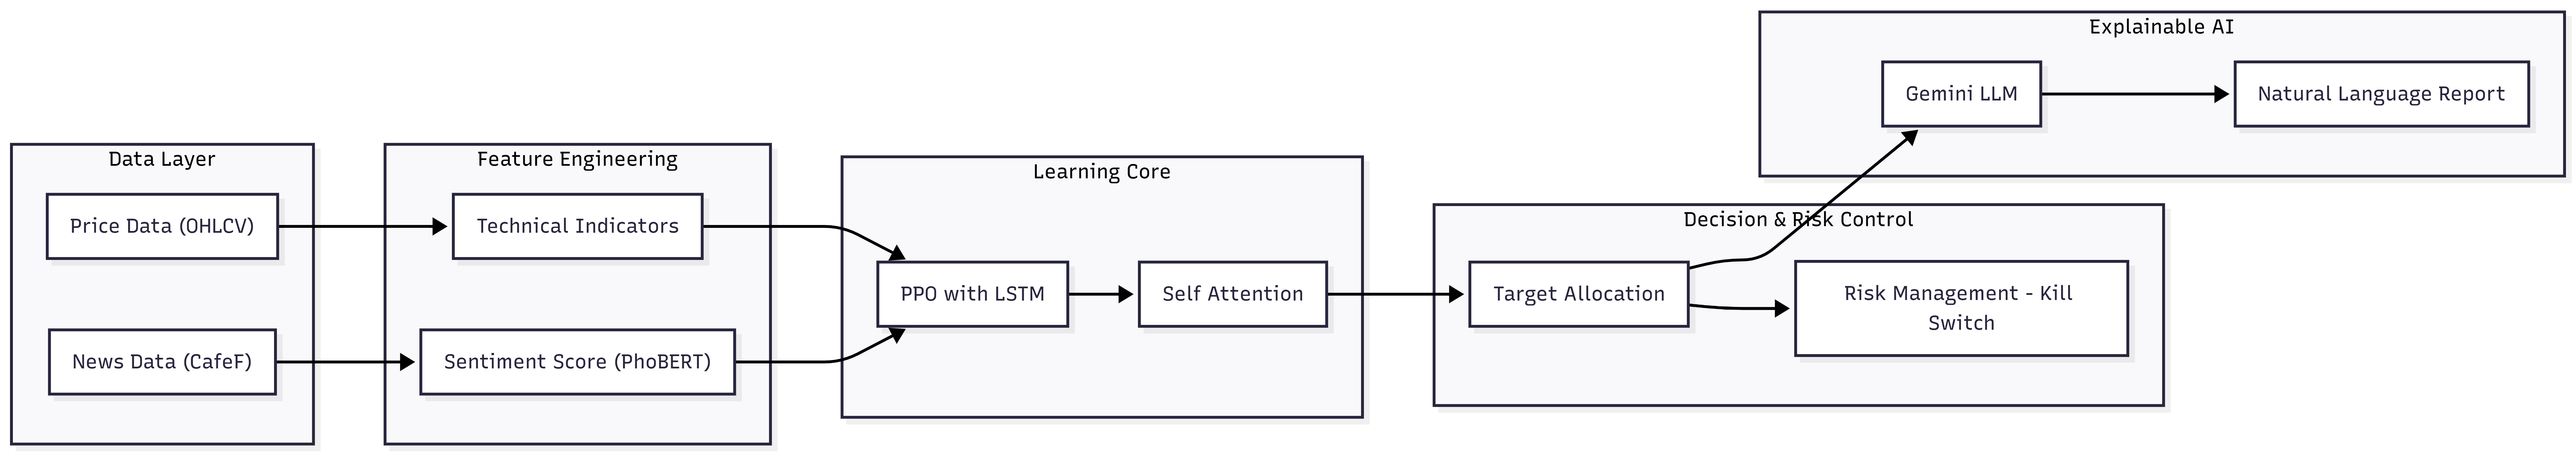

In [1]:
!pip install vnstock ta pandas numpy scikit-learn yfinance GoogleNews requests beautifulsoup4 -q
!pip install transformers torch -q
!pip install gymnasium stable-baselines3 shimmy sb3-contrib -q
!pip install -q -U google-generativeai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.5/41.5 kB 3.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.6/210.6 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 315.5/315.5 kB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.2/93.2 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.1/155.1 kB 14.2 MB/s eta 0:00:00


## **II. PIPELINE THU THẬP DỮ LIỆU ĐA NGUỒN (SMART DATA PIPELINE)**

Trong các bài toán tài chính ứng dụng học máy, chất lượng và độ tin cậy của dữ liệu đầu vào đóng vai trò quyết định đến hiệu quả của mô hình. Thị trường chứng khoán Việt Nam tồn tại nhiều thách thức như dữ liệu phân mảnh, API không ổn định và thiếu đồng bộ giữa các nguồn.

Để giải quyết vấn đề này, chúng tôi xây dựng một **pipeline thu thập dữ liệu thông minh (Smart Data Pipeline)** với kiến trúc **lai và chịu lỗi (Hybrid & Fault-tolerant)**. Pipeline này đảm bảo hệ thống:
- Luôn có dữ liệu đầu vào hợp lệ,
- Tự động chuyển nguồn khi xảy ra sự cố,
- Và duy trì tính toàn vẹn thời gian (Temporal Integrity) cho quá trình huấn luyện mô hình học tăng cường.

---

### **2.1. Dữ liệu Giá và Khối lượng (Market Price Data)**

Dữ liệu lịch sử giá và khối lượng giao dịch là nền tảng cốt lõi để mô hình học được các chu kỳ thị trường và hành vi giá. Hệ thống áp dụng chiến lược **đa nguồn dữ liệu (Multi-source Strategy)** nhằm đảm bảo tính sẵn sàng và độ tin cậy.

- **Nguồn chính (Primary Source): `vnstock`**  
  Hệ thống ưu tiên sử dụng thư viện `vnstock` để truy cập trực tiếp vào dữ liệu từ các công ty chứng khoán nội địa (VCI/TCBS).  
  Ưu điểm của nguồn này bao gồm:
  - Dữ liệu sát với thị trường Việt Nam,
  - Giá đã được điều chỉnh (Adjusted Price),
  - Phù hợp cho các nghiên cứu định lượng dài hạn.

- **Nguồn dự phòng (Fallback Source): `yfinance`**  
  Trong trường hợp API nội địa không phản hồi hoặc gặp lỗi, hệ thống tự động kích hoạt nguồn dữ liệu dự phòng từ Yahoo Finance thông qua thư viện `yfinance`.  
  Cơ chế fallback này đảm bảo pipeline **không bị gián đoạn**, đặc biệt trong các lần huấn luyện kéo dài.

- **Chuẩn hóa dữ liệu đầu vào:**  
  Dữ liệu từ các nguồn khác nhau được đồng bộ về định dạng chuẩn **OHLCV (Open, High, Low, Close, Volume)**, loại bỏ sự khác biệt về cấu trúc trước khi đưa vào bước tiền xử lý và trích xuất đặc trưng.

---

### **2.2. Dữ liệu Tin tức và Sự kiện (Historical News Ingestion)**

Bên cạnh dữ liệu giá, hệ thống tích hợp dữ liệu tin tức nhằm nắm bắt **tâm lý thị trường (Market Sentiment)** — một yếu tố quan trọng nhưng thường bị bỏ qua trong các mô hình giao dịch truyền thống.

- **Custom Ajax Crawler:**  
  Chúng tôi phát triển một module thu thập dữ liệu riêng sử dụng `requests` và `BeautifulSoup4`.  
  Thay vì quét HTML thông thường, module này:
  - Gọi trực tiếp vào các **Endpoint Ajax nội bộ** của cổng thông tin tài chính CafeF,
  - Giảm tải dữ liệu rác,
  - Tăng tốc độ và độ ổn định khi crawl dữ liệu lịch sử.

- **Truy xuất Lịch sử Sâu (Deep Historical Coverage):**  
  Crawler được thiết kế để thu thập dữ liệu tin tức doanh nghiệp trong nhiều năm (từ 2018 đến hiện tại).  
  Điều này cho phép AI học được:
  - Phản ứng của giá trước các sự kiện vĩ mô lớn (COVID-19, khủng hoảng thanh khoản 2022),
  - Hành vi thị trường trong các giai đoạn biến động cực đoan (Black Swan Events).

- **Lọc và Đồng bộ theo thời gian (Temporal Alignment):**  
  Tin tức được:
  - Lọc theo mã cổ phiếu,
  - Chuẩn hóa timestamp về ngày giao dịch,
  - Đồng bộ chính xác với dữ liệu giá.  

  Quy trình này đảm bảo **không xảy ra hiện tượng nhìn trước tương lai (Look-ahead Bias)** — một lỗi nghiêm trọng trong các hệ thống học máy tài chính.

---

### **2.3. Quy trình Lưu trữ và Tiền xử lý Dữ liệu (Data Flow & Preprocessing)**

Sau khi thu thập từ hai luồng chính (Giá và Tin tức), dữ liệu được đưa vào quy trình xử lý thống nhất:

- **Hợp nhất dữ liệu (Data Joining):**  
  Dữ liệu giá và dữ liệu sentiment được hợp nhất thông qua khóa chính là **Ngày giao dịch (Trading Date)**, tạo thành một bảng dữ liệu duy nhất phục vụ huấn luyện.

- **Lưu trữ dữ liệu thô (Raw Data Storage):**  
  Toàn bộ dữ liệu sau khi hợp nhất được lưu trữ dưới dạng DataFrame, giúp:
  - Dễ dàng kiểm soát chất lượng,
  - Truy vết dữ liệu khi debug hoặc tái huấn luyện.

- **Xử lý giá trị khuyết thiếu (Missing Values Handling):**  
  Trong thực tế, không phải ngày giao dịch nào cũng có tin tức.
  - Với các ngày thiếu dữ liệu sentiment, hệ thống áp dụng **Proxy Labeling** dựa trên biến động giá trong ngày,
  - Cách tiếp cận này giúp duy trì tính liên tục của chuỗi thời gian mà không làm gián đoạn không gian trạng thái của Agent.

- **Sẵn sàng cho Feature Engineering:**  
  Sau bước này, dữ liệu đã sẵn sàng để:
  - Chuẩn hóa cuốn chiếu (Walk-forward Scaling),
  - Trích xuất đặc trưng kỹ thuật,
  - Và đưa vào môi trường học tăng cường.

---

**Tóm lại**, Pipeline dữ liệu trong đề tài không chỉ đơn thuần là bước tiền xử lý, mà đóng vai trò như **nền móng đảm bảo tính toàn vẹn, khách quan và độ tin cậy** cho toàn bộ hệ thống AI Trader.


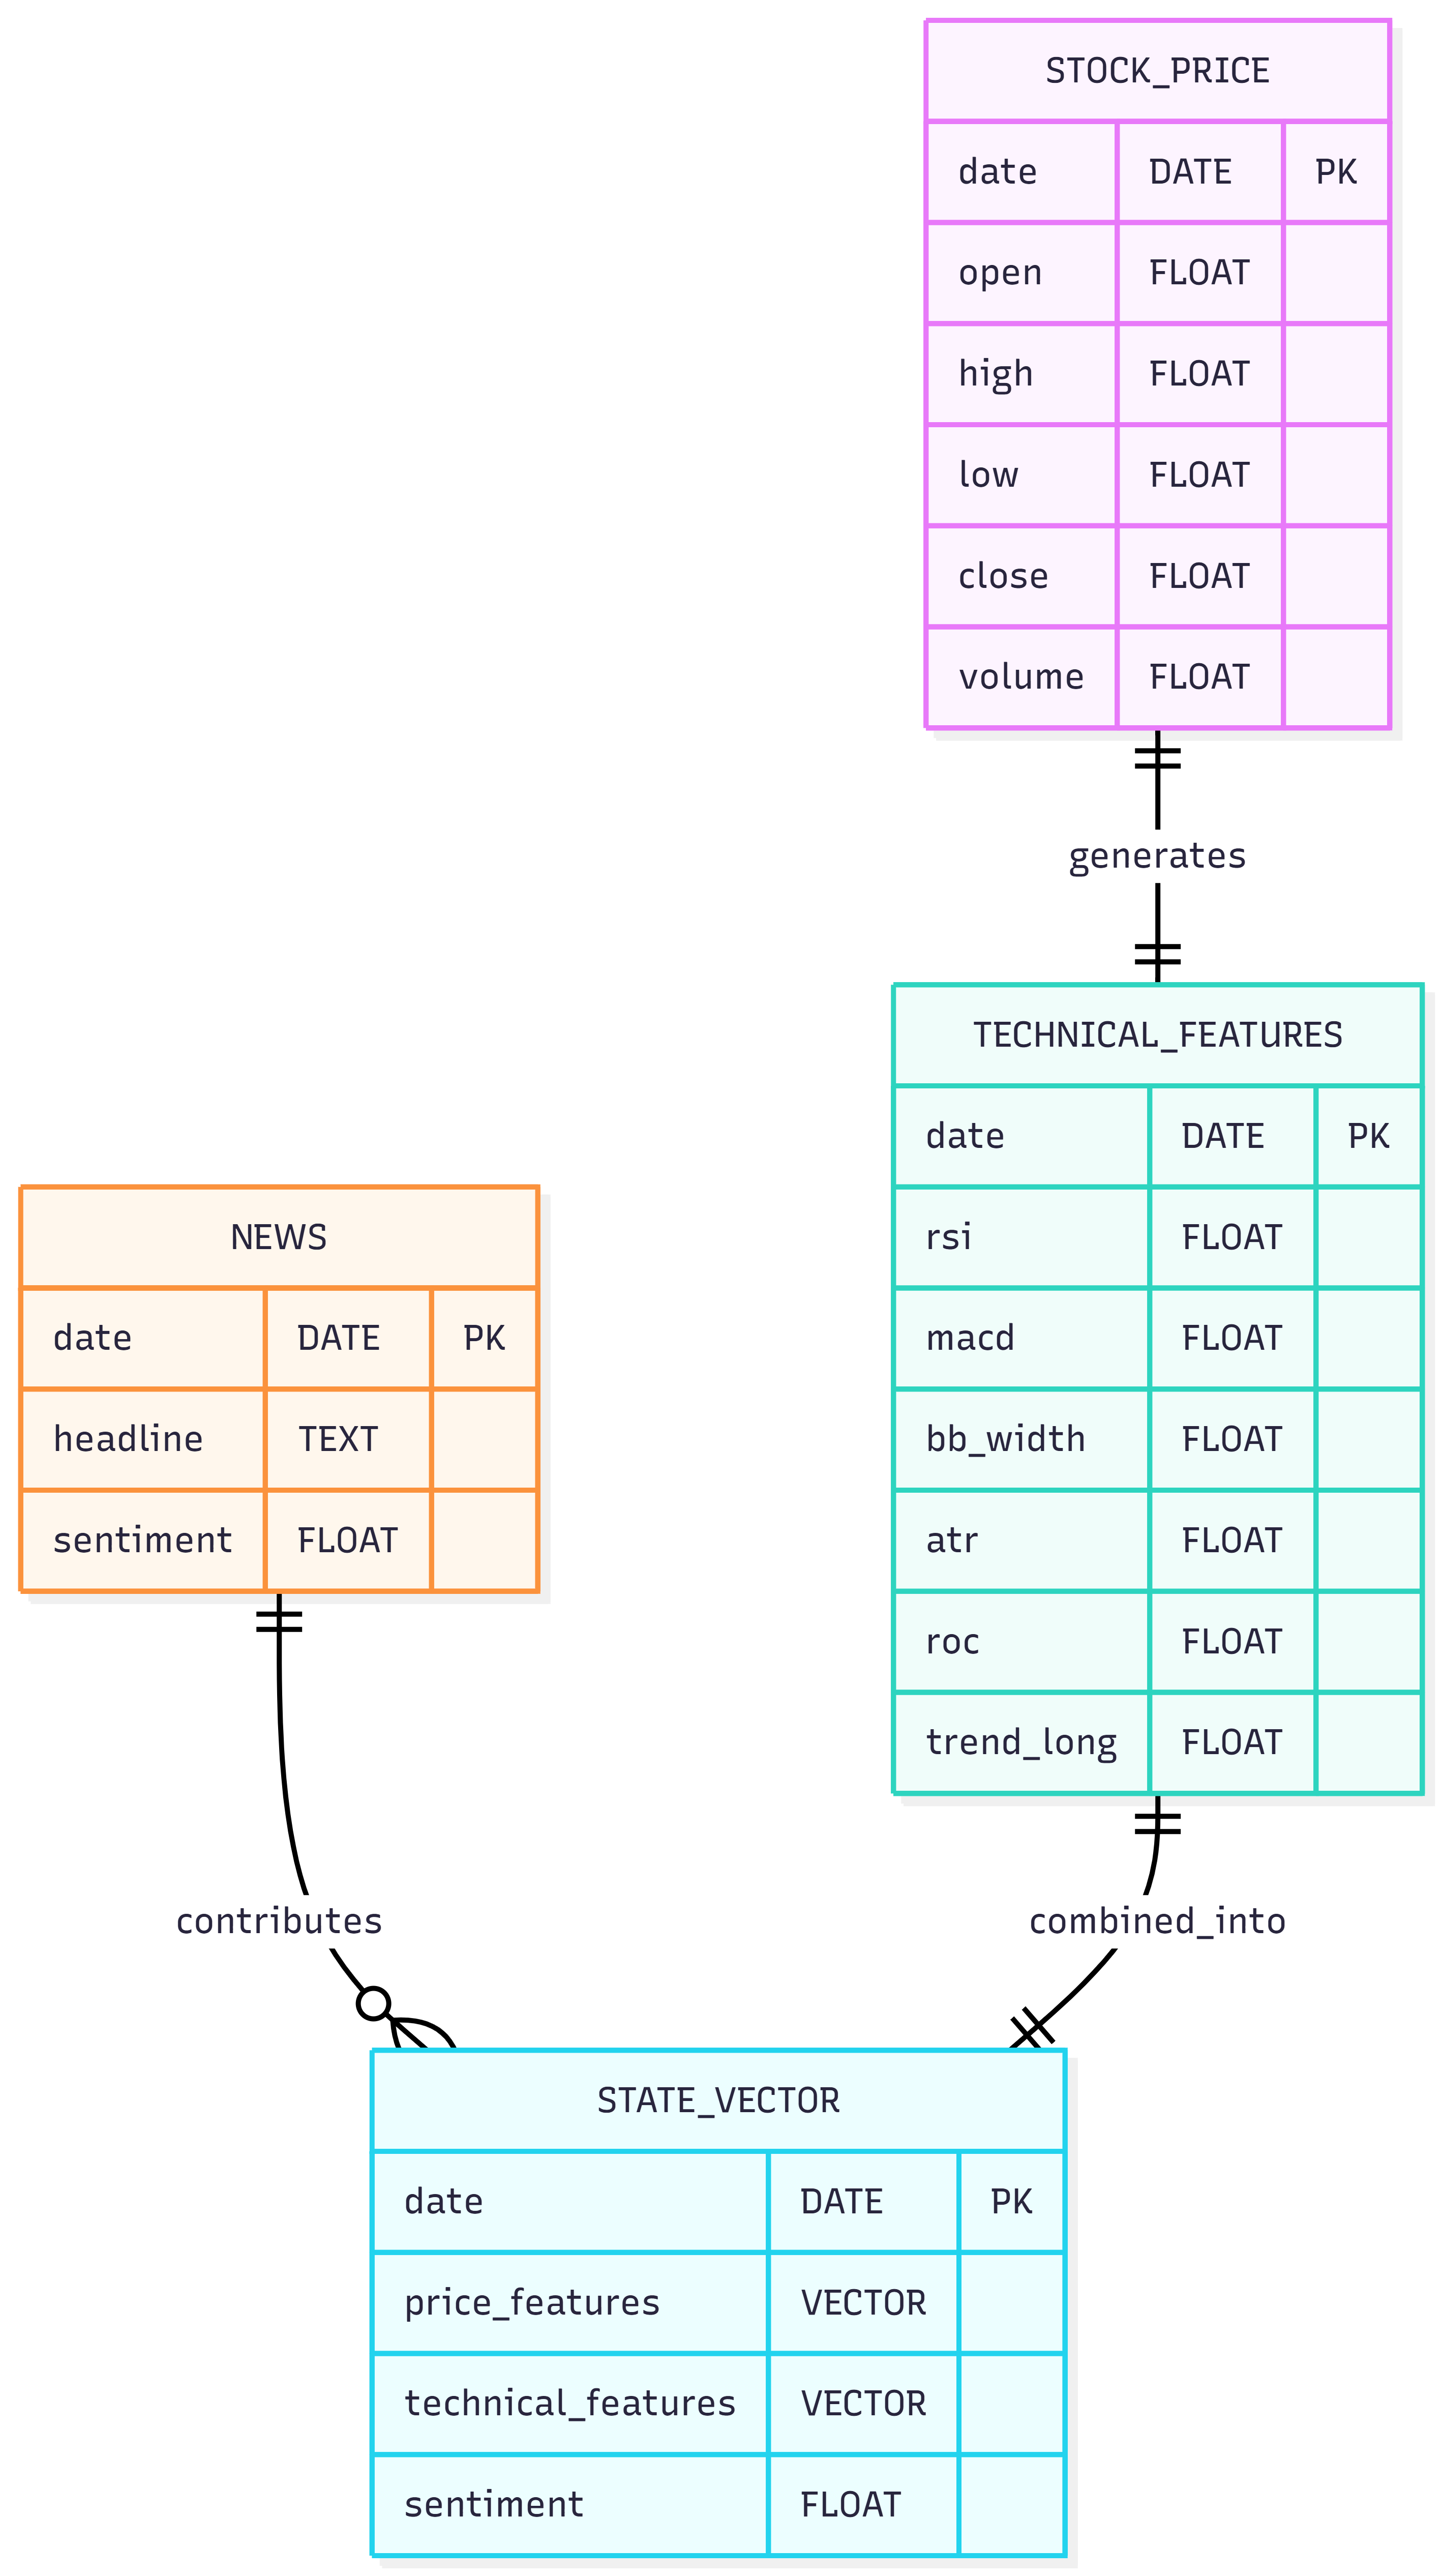

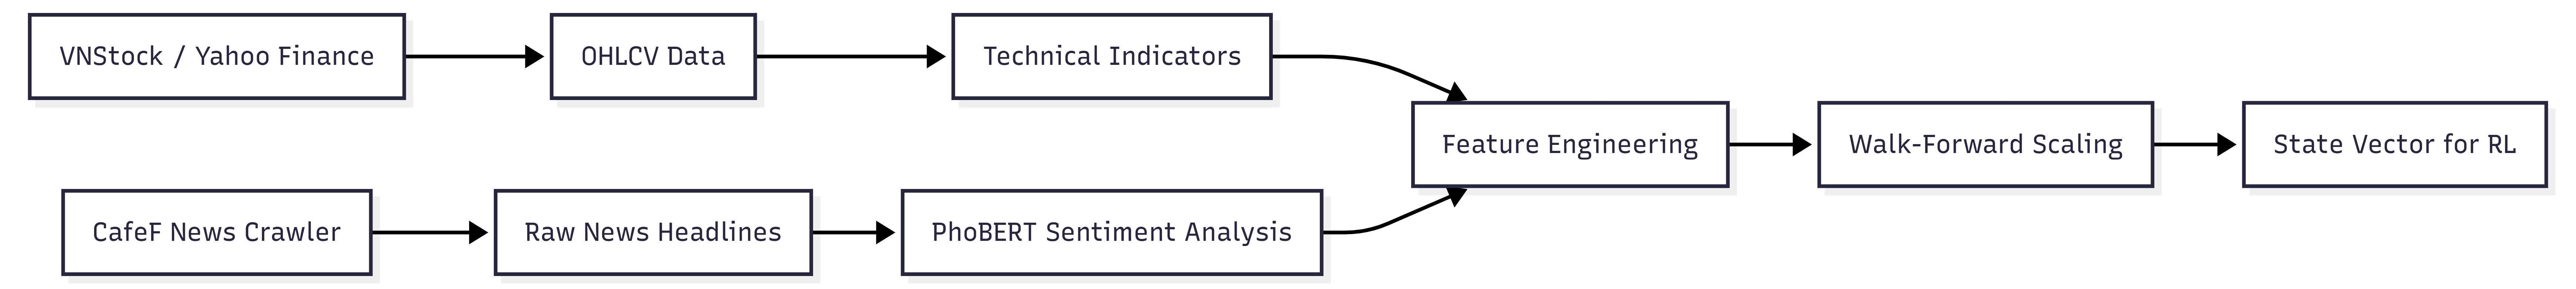

In [2]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import warnings
import time
warnings.filterwarnings('ignore')
import torch
# Google Gemini
from google.colab import userdata
import google.generativeai as genai

# Libraries
from vnstock import Quote
import yfinance as yf
from transformers import pipeline
from ta.trend import MACD, SMAIndicator
from ta.momentum import RSIIndicator, ROCIndicator
from ta.volatility import BollingerBands, AverageTrueRange
from sklearn.preprocessing import MinMaxScaler
import gymnasium as gym
from gymnasium import spaces
import torch
import torch.nn as nn
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor
from sb3_contrib import RecurrentPPO
# --- CẤU HÌNH ---
GEMINI_KEY = userdata.get('GOOGLE_API_KEY')
genai.configure(api_key=GEMINI_KEY)
gemini_model = genai.GenerativeModel('gemini-2.5-flash')

TICKER = 'HPG'
START_DATE = '2016-01-01'
END_DATE = datetime.now().strftime("%Y-%m-%d")
WINDOW_SIZE = 30
INITIAL_CAPITAL = 100_000_000
TIMESTEPS_PER_YEAR = 300_000  # Tăng lên để học tốt hơn

# Các năm để test (walk-forward)
years_to_test = [2020, 2021, 2022, 2023, 2024, 2025]

# Features sử dụng
feature_cols = ['Close', 'Volume', 'rsi', 'macd', 'bb_width', 'trend_long', 'atr', 'roc', 'sentiment']

print(f"✅ Cấu hình: {TICKER} ({START_DATE} -> {END_DATE})")


📋 Connecting Google Drive account
to save project settings.

Mounted at /content/drive


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).


✅ Cấu hình: HPG (2016-01-01 -> 2026-01-05)


In [3]:
import requests
from bs4 import BeautifulSoup

def get_stock_data_smart(symbol, start, end):
    try:
        quote = Quote(symbol=symbol, source='VCI')
        df = quote.history(start=start, end=end, interval='1D')
        if not df.empty:
            df.rename(columns={'close': 'Close', 'volume': 'Volume', 'open': 'Open',
                               'high': 'High', 'low': 'Low', 'time': 'Date'}, inplace=True)
            if 'Date' in df.columns: df['Date'] = pd.to_datetime(df['Date']); df.set_index('Date', inplace=True)
            if df['Close'].iloc[-1] < 1000: df[['Close', 'Open', 'High', 'Low']] *= 1000
            print(f"✅ Lấy giá thành công: {len(df)} phiên.")
            return df
    except: pass
    try:
        df = yf.download(f"{symbol}.VN", start=start, end=end, progress=False)
        if isinstance(df.columns, pd.MultiIndex): df.columns = df.columns.get_level_values(0)
        df.index = df.index.tz_localize(None)
        return df
    except: return pd.DataFrame()

def get_cafef_history_requests(symbol, page_count=50):
    """
    Dùng requests gọi thẳng vào API Ajax của CafeF.
    """
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
    }
    base_url = "https://s.cafef.vn/Ajax/Events_RelatedNews_New.aspx"
    all_news = []

    for page in range(1, page_count + 1):
        try:
            params = {
                'symbol': symbol, 'floorID': 0, 'configID': 0,
                'PageIndex': page, 'PageSize': 20, 'Type': 2
            }

            r = requests.get(base_url, params=params, headers=headers, timeout=5)

            if r.status_code == 200:

                soup = BeautifulSoup(r.text, 'html.parser')
                items = soup.find_all('li')

                if not items: break

                for item in items:
                    try:
                        title = item.find('a', class_='docnhanhTitle')['title']
                        date_str = item.find('span', class_='timeTitle').text.strip()
                        dt = datetime.strptime(date_str, "%d/%m/%Y %H:%M")
                        all_news.append({'date': dt, 'headline': title})
                    except: continue

                if page % 10 == 0: print(f"   ...Đã lấy {len(all_news)} tin (Trang {page})")
                time.sleep(0.1) # Delay nhẹ tránh block
        except: continue

    news_df = pd.DataFrame(all_news)
    if not news_df.empty:
        news_df.drop_duplicates(subset=['headline'], inplace=True)
        news_df['date'] = pd.to_datetime(news_df['date']).dt.normalize()
        news_df.sort_values('date', inplace=True)
        print(f"✅ Tổng cộng crawl được: {len(news_df)} tin tức sạch.")
    else:
        print("⚠️ Không crawl được tin. Dùng dữ liệu giả lập.")
        dates = pd.date_range(start=START_DATE, end=END_DATE, freq='W')
        news_df = pd.DataFrame({'date': dates, 'headline': [f'Tin tức thị trường {symbol}'] * len(dates)})

    return news_df

stock_df = get_stock_data_smart(TICKER, START_DATE, END_DATE)
news_df = get_cafef_history_requests(TICKER, page_count=100)

   ...Đã lấy 200 tin (Trang 10)


datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).


   ...Đã lấy 400 tin (Trang 20)
   ...Đã lấy 600 tin (Trang 30)
   ...Đã lấy 800 tin (Trang 40)
   ...Đã lấy 1000 tin (Trang 50)
   ...Đã lấy 1200 tin (Trang 60)
   ...Đã lấy 1400 tin (Trang 70)
   ...Đã lấy 1600 tin (Trang 80)
   ...Đã lấy 1800 tin (Trang 90)
   ...Đã lấy 2000 tin (Trang 100)
✅ Tổng cộng crawl được: 1902 tin tức sạch.


datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).


In [4]:
stock_df.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2016-01-04,3299.891846,3357.181641,3299.891846,3334.265625,3530546
2016-01-05,3265.517822,3311.349854,3265.517822,3288.433838,5487534
2016-01-06,3322.807617,3322.807617,3265.517822,3265.517822,7858458
2016-01-07,3231.144043,3288.433838,3219.686035,3276.975830,9514162
2016-01-08,3173.854248,3219.686035,3150.938477,3173.854248,8098993


datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).


In [5]:
news_df.head()

,date,headline
1999,2013-06-04,"Khối ngoại mua ròng 1.355 tỷ trong tháng 5, đổ..."
1998,2013-06-05,Giải mã sự tăng nóng của cổ phiếu thép
1997,2013-06-18,HPG: Deutsche Bank AG & Deutsche Asset Managem...
1996,2013-07-08,Những doanh nhân quyền lực và giàu có nhất ngà...
1995,2013-07-11,HPG: Deutsche Bank AG & Deutsche Asset Managem...


datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).


## **III. KỸ THUẬT ĐẶC TRƯNG & XỬ LÝ DỮ LIỆU (FEATURE ENGINEERING)**

Trong bài toán giao dịch tài chính, dữ liệu thị trường mang tính nhiễu cao, phi tuyến mạnh và thay đổi liên tục theo thời gian (Concept Drift). Vì vậy, mục tiêu của Feature Engineering trong đề tài này không phải là tạo ra thật nhiều chỉ báo, mà là xây dựng một **không gian trạng thái ổn định, có ý nghĩa kinh tế và phù hợp cho học tăng cường**.

Hệ thống áp dụng chiến lược **đa đặc trưng (Multi-factor Representation)**, kết hợp giữa phân tích kỹ thuật, phân tích tâm lý thị trường và các kỹ thuật xử lý dữ liệu nghiêm ngặt nhằm đảm bảo tính toàn vẹn của quá trình huấn luyện.

---

### **3.1. Đặc trưng Kỹ thuật (Technical Indicators)**

Từ dữ liệu OHLCV (Open, High, Low, Close, Volume), hệ thống trích xuất các chỉ báo kỹ thuật đại diện cho ba khía cạnh cốt lõi của thị trường: **động lượng, biến động và xu hướng**.

**Nhóm Động lượng (Momentum):**
- **RSI (Relative Strength Index):** phản ánh trạng thái quá mua, quá bán và vùng cân bằng của thị trường.
- **MACD:** thể hiện sự thay đổi động lực giá thông qua mối quan hệ giữa xu hướng ngắn hạn và dài hạn.

**Nhóm Biến động (Volatility):**
- **Bollinger Band Width:** đo mức độ mở rộng của biên độ giá, đại diện cho mức độ bất ổn và rủi ro thị trường.
- **ATR (Average True Range):** cung cấp thước đo trực tiếp về biên độ dao động giá trong từng phiên giao dịch.

**Nhóm Xu hướng (Trend Filter):**
- Hệ thống sử dụng đường trung bình động 50 phiên (SMA50) để xác định xu hướng dài hạn.
- Đặc trưng `trend_long` được tính bằng tỷ lệ chênh lệch giữa giá đóng cửa và SMA50.
- Khi `trend_long` dương, thị trường được xem là có xu hướng tăng; ngược lại là xu hướng giảm.

Đặc trưng xu hướng đóng vai trò then chốt trong việc giúp AI phân biệt giữa thị trường có xu hướng rõ ràng (Trending) và thị trường đi ngang (Sideways).

---

### **3.2. Phân tích Tình cảm & Proxy Labeling (Sentiment Analysis)**

Bên cạnh dữ liệu giá, hệ thống tích hợp dữ liệu tin tức nhằm phản ánh **tâm lý thị trường**, một yếu tố quan trọng nhưng thường bị bỏ qua trong các chiến lược truyền thống.

**Phân tích NLP bằng PhoBERT:**
- Các tiêu đề tin tức tài chính được phân tích bằng mô hình NLP tiếng Việt `PhoBERT`.
- Mỗi tiêu đề được mã hóa thành tín hiệu sentiment:
  - Tích cực: +1
  - Trung tính: 0
  - Tiêu cực: -1
- Với mỗi ngày giao dịch, sentiment được tính bằng **giá trị trung bình** của các tin tức trong ngày đó.

**Proxy Labeling khi thiếu tin tức:**
Trong thực tế, không phải phiên giao dịch nào cũng có tin tức liên quan đến doanh nghiệp. Để tránh dữ liệu khuyết thiếu trong không gian trạng thái, hệ thống áp dụng chiến lược **Proxy Sentiment**:

- Nếu **giá đóng cửa tăng so với phiên trước** → gán sentiment = +0.5
- Nếu **giá đóng cửa giảm** → gán sentiment = -0.5

Cách tiếp cận này giúp:
- Duy trì tính liên tục của chuỗi thời gian.
- Phản ánh tâm lý thị trường ngầm thông qua hành vi giá.
- Tránh việc đưa tín hiệu sentiment quá mạnh khi không có dữ liệu tin tức thực.

---

### **3.3. Chuẩn hóa Cuốn chiếu (Walk-Forward Scaling)**

Để đảm bảo tính khách quan và tránh lỗi nhìn trước dữ liệu tương lai (Look-ahead Bias), hệ thống không sử dụng chuẩn hóa toàn cục.

Thay vào đó, hệ thống áp dụng **Walk-Forward Scaling** với nguyên tắc:
- Bộ MinMaxScaler chỉ được huấn luyện (fit) trên tập dữ liệu quá khứ trong từng giai đoạn huấn luyện.
- Dữ liệu kiểm thử chỉ được biến đổi (transform) dựa trên thông tin của quá khứ.

Cách chuẩn hóa này mô phỏng chính xác điều kiện giao dịch thực tế và đảm bảo rằng mô hình không vô tình sử dụng thông tin tương lai trong quá trình học.

---

### **3.4. Cơ chế Chú ý (Self-Attention Layer)**

Không phải mọi phiên giao dịch trong cửa sổ 30 ngày đều có mức độ quan trọng như nhau. Vì vậy, trước khi dữ liệu được đưa vào mạng chính sách của PPO, hệ thống sử dụng **Self-Attention** để:

- Gán trọng số cao hơn cho các phiên có biến động mạnh, xu hướng rõ ràng hoặc tín hiệu sentiment bất thường.
- Giảm ảnh hưởng của các phiên ít thông tin hoặc mang tính nhiễu.

Cơ chế Attention cho phép mô hình tập trung vào các thời điểm quan trọng trong chuỗi thời gian, từ đó cải thiện chất lượng biểu diễn trạng thái và hỗ trợ Agent đưa ra quyết định phân bổ tỷ trọng hiệu quả hơn.


In [6]:
if not stock_df.empty:
    stock_df['rsi'] = RSIIndicator(close=stock_df['Close'], window=14).rsi()
    stock_df['macd'] = MACD(close=stock_df['Close']).macd()
    bb = BollingerBands(close=stock_df['Close'], window=20, window_dev=2)
    stock_df['bb_width'] = bb.bollinger_wband()
    stock_df['sma_50'] = SMAIndicator(close=stock_df['Close'], window=50).sma_indicator()
    stock_df['trend_long'] = (stock_df['Close'] - stock_df['sma_50']) / stock_df['sma_50']
    stock_df['atr'] = AverageTrueRange(high=stock_df['High'], low=stock_df['Low'], close=stock_df['Close']).average_true_range()
    stock_df['roc'] = ROCIndicator(close=stock_df['Close'], window=12).roc()
    stock_df.dropna(inplace=True)
    print("🧠 Đang xử lý NLP Sentiment (PhoBERT)...")
    try:
        device = 0 if torch.cuda.is_available() else -1
        pipe = pipeline("sentiment-analysis", model="wonrax/phobert-base-vietnamese-sentiment", device=device)
        def batch_predict(texts):
            results = []
            for i in range(0, len(texts), 50):
                batch = texts[i:i+50]
                preds = pipe([str(t)[:256] for t in batch])
                results.extend([1 if p['label']=='POS' else (-1 if p['label']=='NEG' else 0) for p in preds])
            return results

        valid_news = news_df[news_df['date'].isin(stock_df.index)]
        if not valid_news.empty:
            valid_news['sentiment'] = batch_predict(valid_news['headline'].tolist())
            daily_sentiment = valid_news.groupby('date')['sentiment'].mean()
        else:
            daily_sentiment = pd.Series(dtype=float)

    except Exception as e:
        print(f"⚠️ Lỗi NLP: {e}. Dùng Proxy Labeling.")
        daily_sentiment = pd.Series(dtype=float)

    full_df = stock_df.join(daily_sentiment, how='left')

    mask_null = full_df['sentiment'].isnull()
    full_df.loc[mask_null, 'sentiment'] = np.where(full_df.loc[mask_null, 'Close'].pct_change() > 0, 0.5, -0.5)

    raw_df = full_df.copy()
    print(f"✅ Dữ liệu thô sẵn sàng: {raw_df.shape}")

🧠 Đang xử lý NLP Sentiment (PhoBERT)...


datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).


config.json:   0%|          | 0.00/999 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/540M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/285 [00:00<?, ?B/s]

...

added_tokens.json:   0%|          | 0.00/17.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

Device set to use cuda:0
You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


✅ Dữ liệu thô sẵn sàng: (2448, 13)


datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).


In [7]:
raw_df.head(5)

,Close,High,Low,Open,Volume,rsi,macd,bb_width,sma_50,trend_long,atr,roc,sentiment
Date,,,,,,,,,,,,,
2016-03-18,3403.013428,3448.845215,3403.013428,3448.845215,33109292,65.316403,82.965448,15.248109,3145.209395,0.081967,80.950798,9.191178,0.0
2016-03-21,3414.471436,3471.761230,3414.471436,3425.929443,13871748,66.074929,83.363125,15.363489,3147.500986,0.084820,80.079155,10.370368,-0.5
2016-03-22,3380.097412,3425.929443,3380.097412,3425.929443,13989921,61.714403,79.982602,15.060351,3149.792578,0.073117,77.632932,7.272720,0.0
2016-03-23,3357.181641,3403.013428,3334.265625,3357.181641,15152954,58.922673,74.594522,14.489120,3150.480059,0.065610,76.998280,5.395684,0.0
2016-03-24,3299.891846,3391.555420,3299.891846,3345.723633,15926214,52.525546,64.952886,13.769692,3151.855015,0.046968,78.045801,-0.346022,-0.5


datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).


## **IV. THIẾT KẾ MÔI TRƯỜNG GIAO DỊCH (TARGET ALLOCATION ENVIRONMENT)**

Môi trường giao dịch là thành phần trung tâm trong hệ thống học tăng cường, đóng vai trò cầu nối giữa dữ liệu thị trường thực tế và quá trình ra quyết định của Agent. Trong đề tài này, môi trường được xây dựng tuân thủ chuẩn **Gymnasium**, mô phỏng một kịch bản giao dịch sát với thực tế, nơi AI đóng vai trò là **nhà quản lý danh mục đầu tư (Portfolio Manager)**.

Khác với các môi trường giao dịch đơn giản chỉ tập trung vào mua/bán, môi trường này được thiết kế xoay quanh **bài toán phân bổ tỷ trọng vốn (Target Allocation)** và tối ưu hóa hiệu quả **điều chỉnh theo rủi ro (Risk-adjusted Performance)**.

---

### **4.1. Không gian Hành động – Target Allocation (Action Space)**

Hệ thống sử dụng **không gian hành động liên tục**, trong đó mỗi hành động của Agent là một giá trị thực trong khoảng từ 0 đến 1.

- Giá trị hành động đại diện cho **tỷ trọng vốn mục tiêu** được phân bổ vào cổ phiếu.
- Phần vốn còn lại được giữ ở dạng tiền mặt.

Diễn giải kinh tế:
- **0.0 (Full Cash):** Đứng ngoài thị trường, ưu tiên bảo toàn vốn khi rủi ro cao.
- **0.5 (Balanced):** Trạng thái trung lập, phân bổ cân bằng giữa cổ phiếu và tiền mặt.
- **1.0 (Full Stock):** Giải ngân tối đa, thể hiện niềm tin mạnh vào xu hướng tăng.

Cách tiếp cận này phản ánh đúng thực tế quản lý quỹ, nơi nhà đầu tư điều chỉnh **quy mô vị thế** thay vì chỉ quyết định mua hay bán.

---

### **4.2. Cơ chế Tái cân bằng Danh mục (Dynamic Rebalancing)**

Tại mỗi bước thời gian, môi trường tự động điều chỉnh danh mục thực tế để tiến gần đến tỷ trọng mục tiêu do Agent đề xuất.

Quy trình tái cân bằng bao gồm:
- Tính toán tổng tài sản hiện tại (tiền mặt + giá trị cổ phiếu).
- Xác định giá trị cổ phiếu mục tiêu dựa trên tỷ trọng hành động.
- Thực hiện mua hoặc bán nếu độ lệch vượt quá một **ngưỡng tối thiểu (min_trade_threshold)**.

Cơ chế này giúp:
- Giảm giao dịch nhỏ lẻ không cần thiết.
- Hạn chế chi phí giao dịch và nhiễu trong quá trình học.
- Mô phỏng sát hành vi tái cân bằng danh mục trong thực tế.

---

### **4.3. Mô hình Chi phí & Thực thi Giao dịch**

Để tăng tính thực tế, môi trường mô phỏng các yếu tố ma sát thị trường:

- **Chi phí giao dịch:** Áp dụng phí mua và bán cố định cho mỗi lần khớp lệnh.
- **Slippage:** Giá thực thi được nhiễu nhẹ quanh giá thị trường nhằm phản ánh độ trễ và thanh khoản không hoàn hảo.
- **Giao dịch nguyên lô:** Số lượng cổ phiếu mua/bán được làm tròn xuống, tránh giả định giao dịch phân số không thực tế.

Những yếu tố này buộc Agent phải học cách giao dịch hiệu quả, thay vì khai thác các giả định lý tưởng hóa.

---

### **4.4. Không gian Trạng thái (Observation Space)**

Tại mỗi thời điểm, Agent quan sát một **cửa sổ trượt gồm 30 phiên giao dịch gần nhất**, bao gồm:

- **Dữ liệu giá và khối lượng:** Close, Volume.
- **Chỉ báo kỹ thuật:** RSI, MACD, Bollinger Band Width, ATR, ROC.
- **Đặc trưng xu hướng:** trend_long (dựa trên SMA50).
- **Tín hiệu NLP:** Sentiment từ tin tức hoặc Proxy Sentiment khi không có tin.

Toàn bộ đặc trưng được chuẩn hóa trước khi đưa vào môi trường, giúp ổn định quá trình huấn luyện.

---

### **4.5. Hàm Thưởng – Tối ưu Hiệu quả Điều chỉnh theo Rủi ro (Reward Function)**

Khác với các môi trường truyền thống tối ưu hóa lợi nhuận tuyệt đối, hàm thưởng trong đề tài này được thiết kế để **đánh giá hiệu suất tương đối so với thị trường**, đồng thời phản ánh khả năng quản trị rủi ro của Agent.

Các thành phần chính của hàm thưởng bao gồm:

**Hiệu suất tương đối (Relative Performance):**
- Agent được thưởng khi lợi nhuận danh mục vượt trội so với lợi nhuận thị trường, có điều chỉnh theo mức độ tham gia (tỷ trọng).

**Nhận diện trạng thái thị trường (Regime-aware Reward):**
- Trong thị trường tăng (bull regime), Agent được khuyến khích tham gia thị trường nhiều hơn.
- Trong thị trường giảm (bear regime), Agent được thưởng khi giảm tỷ trọng và bảo vệ vốn hiệu quả.

**Phạt giao dịch quá mức (Turnover Penalty):**
- Thay đổi tỷ trọng quá đột ngột giữa các bước bị phạt nhằm khuyến khích chiến lược mượt và ổn định.

**Phạt suy giảm tài sản (Soft Drawdown Penalty):**
- Khi giá trị danh mục giảm sâu so với đỉnh trước đó, Agent bị phạt theo mức độ drawdown.
- Không sử dụng cơ chế cắt lỗ cưỡng bức cứng, thay vào đó để Agent tự học cách kiểm soát rủi ro thông qua hàm thưởng.

Thiết kế này giúp Agent học được hành vi của một nhà quản lý danh mục chuyên nghiệp: **không chỉ kiếm lợi nhuận, mà còn biết khi nào nên đứng ngoài để bảo vệ vốn**.


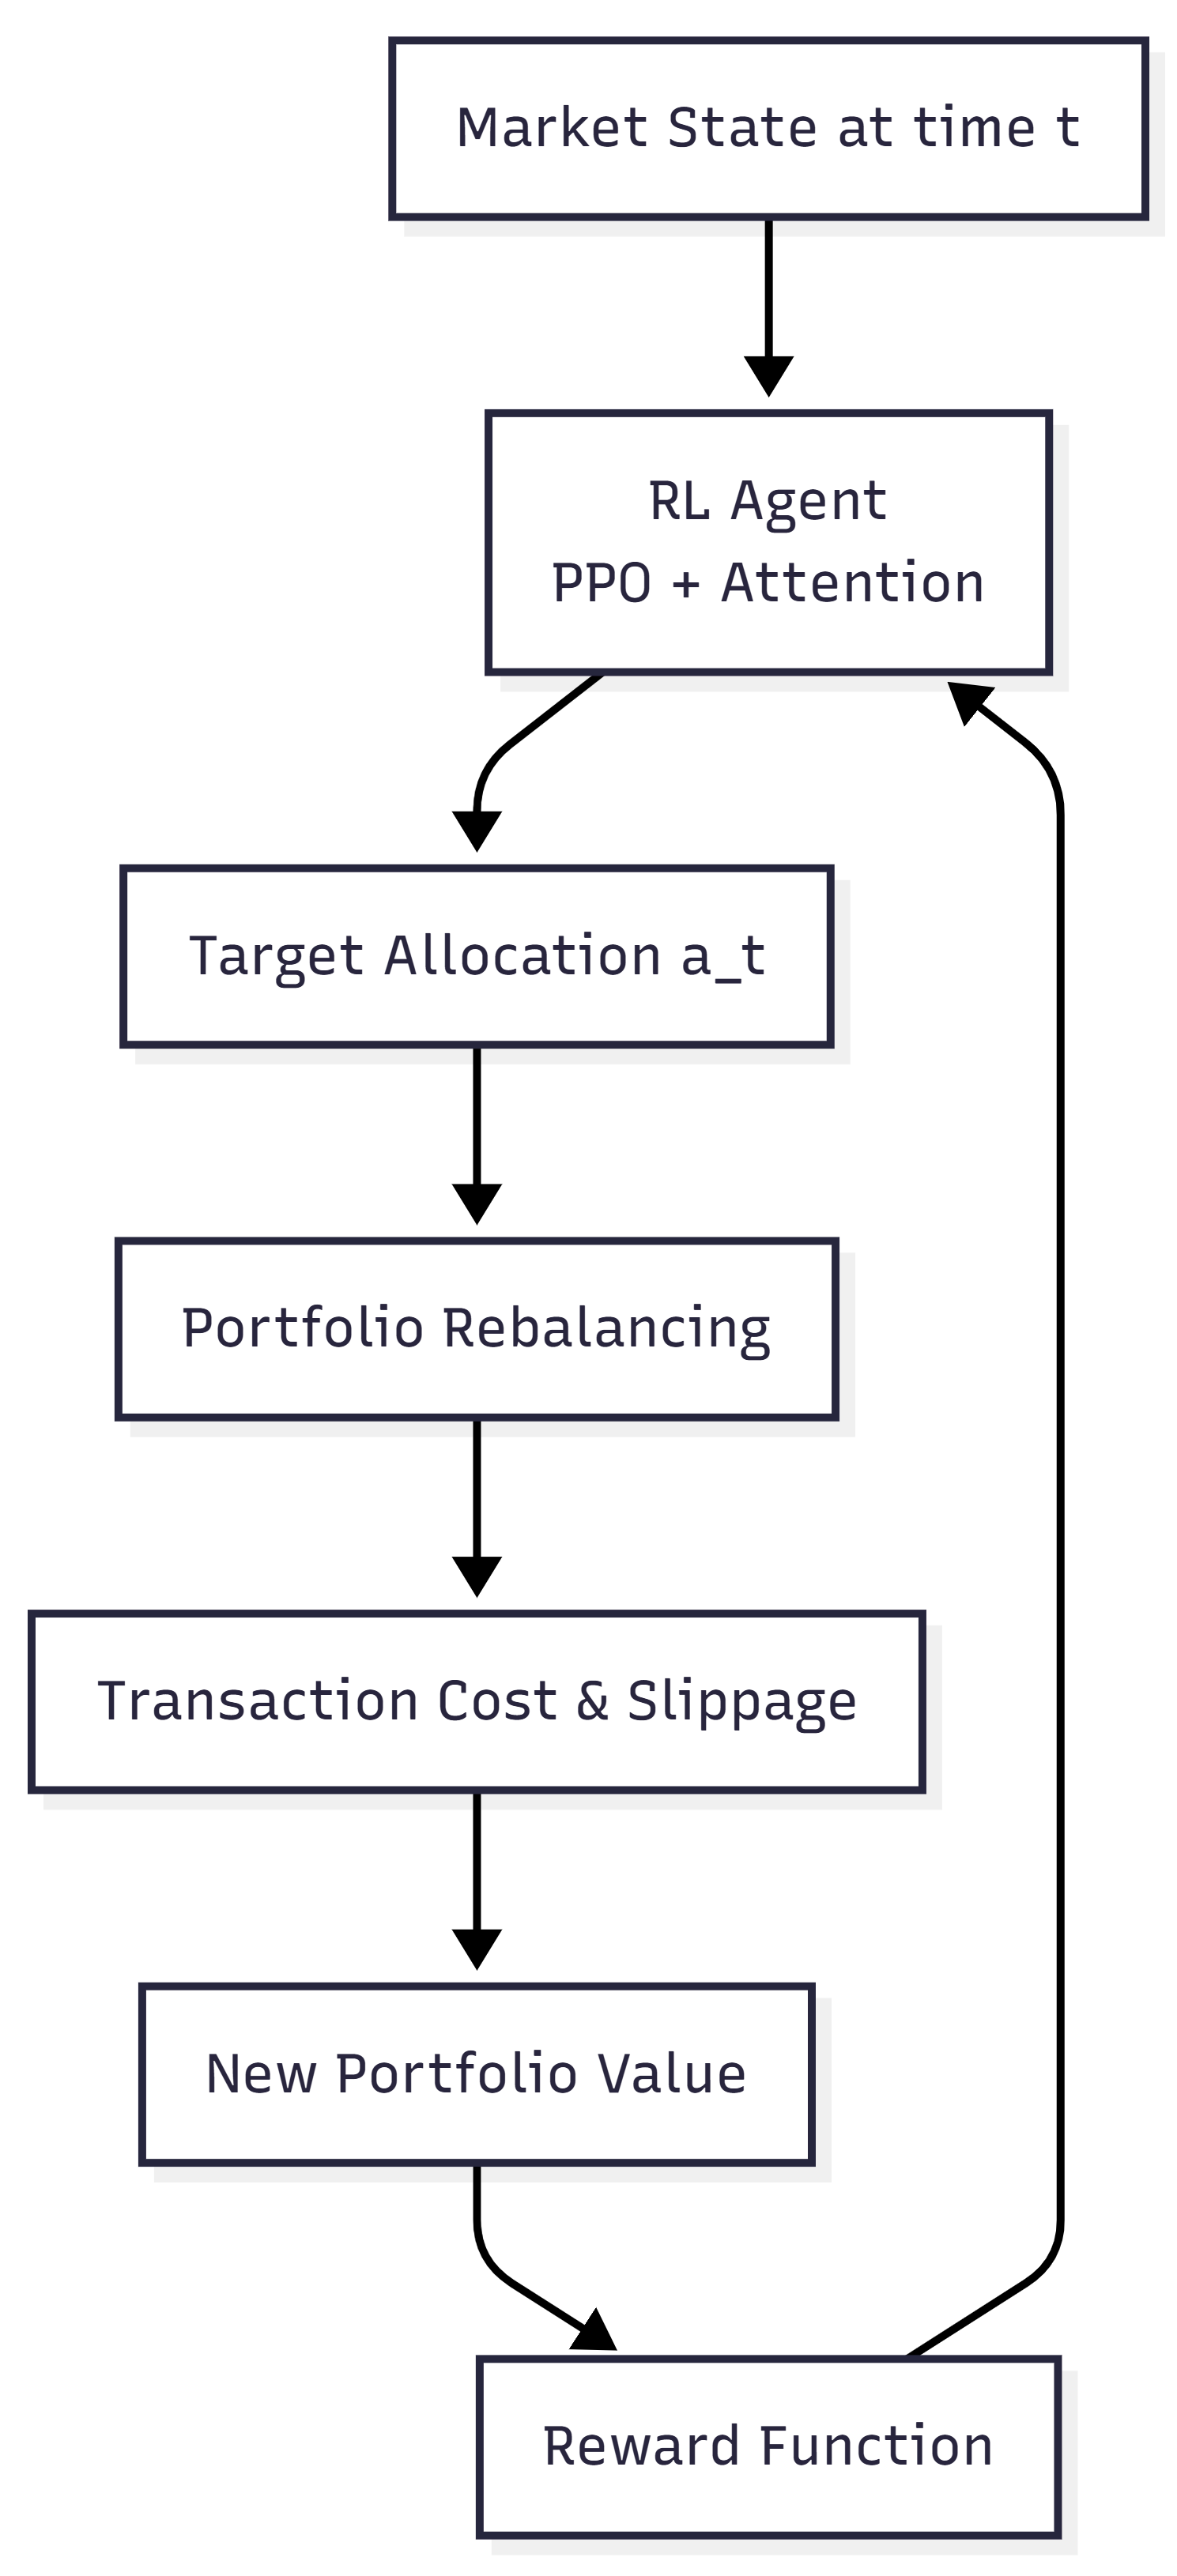

In [8]:
# class AttentionFeatureExtractor(BaseFeaturesExtractor):
#     def __init__(self, observation_space, features_dim=128):
#         super().__init__(observation_space, features_dim)
#         self.input_dim = observation_space.shape[1]
#         self.attention = nn.MultiheadAttention(embed_dim=self.input_dim, num_heads=1, batch_first=True)
#         self.linear = nn.Sequential(
#             nn.Flatten(),
#             nn.Linear(observation_space.shape[0] * self.input_dim, features_dim),
#             nn.ReLU()
#         )

#     def forward(self, observations):
#         attn_output, _ = self.attention(observations, observations, observations)
#         return self.linear(observations + attn_output) # Residual connection

In [9]:
class AttentionFeatureExtractor(BaseFeaturesExtractor):
    def __init__(self, observation_space, features_dim=128, num_heads=4):
        super().__init__(observation_space, features_dim)

        self.window_size = observation_space.shape[0]
        self.input_dim = observation_space.shape[1]

        # Project 9 → 12 (chia hết cho 4)
        self.proj = nn.Linear(self.input_dim, 12)

        self.attention = nn.MultiheadAttention(
            embed_dim=12,
            num_heads=num_heads,
            batch_first=True
        )

        self.pooling = nn.AdaptiveAvgPool1d(1)

        self.fc = nn.Sequential(
            nn.Linear(12, features_dim),
            nn.ReLU()
        )

    def forward(self, obs):
        x = self.proj(obs)                 # (B, T, 12)
        attn_out, _ = self.attention(x, x, x)
        x = x + attn_out                   # Residual
        x = x.transpose(1, 2)
        x = self.pooling(x).squeeze(-1)
        return self.fc(x)


In [10]:
# code cũ
# class QuantTradingEnv(gym.Env):
#     def __init__(self, raw_df, scaled_data, initial_balance=100_000_000, window_size=30):
#         super().__init__()
#         self.raw_df = raw_df.reset_index(drop=True)
#         self.scaled_data = scaled_data
#         self.initial_balance = initial_balance
#         self.window_size = window_size

#         self.action_space = spaces.Box(low=np.array([0]), high=np.array([1]), dtype=np.float32)
#         self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(window_size, 9), dtype=np.float32)

#     def reset(self, seed=None):
#         super().reset(seed=seed)
#         self.balance = self.initial_balance
#         self.shares = 0
#         self.net_worth = self.initial_balance
#         self.max_net_worth = self.initial_balance
#         self.current_step = self.window_size
#         return self._get_obs(), {}

#     def _get_obs(self):
#         return self.scaled_data[self.current_step - self.window_size : self.current_step].astype(np.float32)

#     def step(self, action):
#         target_weight = np.clip(action[0], 0, 1)
#         current_price = self.raw_df.loc[self.current_step, 'Close']
#         if self.shares > 0:
#             avg_cost = (self.initial_balance - self.balance) / self.shares
#             if current_price < avg_cost * 0.93:
#                 target_weight = 0.0

#         current_stock_val = self.shares * current_price
#         total_assets = self.balance + current_stock_val
#         target_stock_val = total_assets * target_weight
#         delta = target_stock_val - current_stock_val

#         if delta > total_assets * 0.01:
#             cost = min(delta, self.balance)
#             if cost > current_price:
#                 shares_buy = int(cost / current_price)
#                 self.balance -= shares_buy * current_price * 1.0015 # Phí 0.15%
#                 self.shares += shares_buy
#         elif delta < -total_assets * 0.01:
#             sell_val = abs(delta)
#             shares_sell = int(sell_val / current_price)
#             shares_sell = min(shares_sell, self.shares)
#             if shares_sell > 0:
#                 self.balance += shares_sell * current_price * 0.9985
#                 self.shares -= shares_sell

#         self.current_step += 1

#         next_price = self.raw_df.loc[self.current_step, 'Close']
#         self.net_worth = self.balance + (self.shares * next_price)
#         self.max_net_worth = max(self.max_net_worth, self.net_worth)

#         profit_pct = (self.net_worth - self.initial_balance) / self.initial_balance
#         reward = profit_pct * 100
#         if (self.net_worth - self.max_net_worth) / self.max_net_worth < -0.15: reward -= 2.0

#         done = self.current_step >= len(self.raw_df) - 1
#         return self._get_obs(), reward, done, False, {}

In [11]:
class QuantTradingEnv(gym.Env):
    """
    Quantitative Trading Environment with continuous portfolio allocation.
    FIXED VERSION:
    - Relative performance vs market
    - Regime-aware reward
    - Softer, delayed drawdown penalty
    """

    metadata = {"render_modes": []}

    def __init__(
        self,
        raw_df,
        scaled_data,
        initial_balance=100_000_000,
        window_size=30,
        transaction_cost=0.0015,
        min_trade_threshold=0.005,
        max_episode_steps=200
    ):
        super().__init__()

        self.raw_df = raw_df.reset_index(drop=True)
        self.scaled_data = scaled_data

        self.initial_balance = initial_balance
        self.window_size = window_size
        self.transaction_cost = transaction_cost
        self.min_trade_threshold = min_trade_threshold
        self.max_episode_steps = max_episode_steps

        self.action_space = spaces.Box(
            low=np.array([0.0]),
            high=np.array([1.0]),
            dtype=np.float32
        )

        self.observation_space = spaces.Box(
            low=-np.inf,
            high=np.inf,
            shape=(window_size, scaled_data.shape[1]),
            dtype=np.float32
        )

    # ====================================================
    # RESET
    # ====================================================
    def reset(self, seed=None):
        super().reset(seed=seed)

        self.current_step = np.random.randint(
            self.window_size,
            len(self.raw_df) - self.max_episode_steps
        )

        self.balance = self.initial_balance
        self.shares = 0
        self.net_worth = self.initial_balance
        self.prev_net_worth = self.initial_balance
        self.max_net_worth = self.initial_balance

        self.prev_action = 0.5
        self.holding_period = 0
        self.total_trades = 0
        self.steps_in_episode = 0

        return self._get_obs(), {}

    def _get_obs(self):
        return self.scaled_data[
            self.current_step - self.window_size : self.current_step
        ].astype(np.float32)

    # ====================================================
    # STEP
    # ====================================================
    def step(self, action):
        self.steps_in_episode += 1
        target_weight = float(np.clip(action[0], 0.0, 1.0))

        current_price = self.raw_df.loc[self.current_step, "Close"]
        prev_price = self.raw_df.loc[self.current_step - 1, "Close"]

        execution_price = current_price * np.random.uniform(0.999, 1.001)
        self.prev_net_worth = self.net_worth

        # ===== Rebalancing =====
        current_stock_value = self.shares * execution_price
        total_assets = self.balance + current_stock_value
        target_stock_value = total_assets * target_weight
        delta_value = target_stock_value - current_stock_value

        trade_executed = False

        if delta_value > total_assets * self.min_trade_threshold:
            cash_to_spend = min(delta_value, self.balance)
            shares_buy = int(cash_to_spend / execution_price)
            if shares_buy > 0:
                cost = shares_buy * execution_price * (1 + self.transaction_cost)
                if cost <= self.balance:
                    self.balance -= cost
                    self.shares += shares_buy
                    trade_executed = True
                    self.total_trades += 1
                    self.holding_period = 0

        elif delta_value < -total_assets * self.min_trade_threshold:
            sell_value = abs(delta_value)
            shares_sell = min(int(sell_value / execution_price), self.shares)
            if shares_sell > 0:
                revenue = shares_sell * execution_price * (1 - self.transaction_cost)
                self.balance += revenue
                self.shares -= shares_sell
                trade_executed = True
                self.total_trades += 1

        self.current_step += 1
        if self.shares > 0:
            self.holding_period += 1

        next_price = self.raw_df.loc[self.current_step, "Close"]
        self.net_worth = self.balance + self.shares * next_price
        self.max_net_worth = max(self.max_net_worth, self.net_worth)

        reward, reward_components = self._calculate_reward(
            target_weight, current_price, prev_price, next_price, trade_executed
        )

        done = (
            self.steps_in_episode >= self.max_episode_steps
            or self.current_step >= len(self.raw_df) - 1
        )

        info = {
            "net_worth": self.net_worth,
            "total_trades": self.total_trades,
            "reward_components": reward_components,
            "target_weight": target_weight,
            "confidence": abs(target_weight - 0.5) * 2
        }

        self.prev_action = target_weight
        return self._get_obs(), reward, done, False, info


    def _calculate_reward(self, target_weight, current_price, prev_price, next_price, trade_executed):
        reward = 0.0
        components = {}

        # 1. Agent return
        agent_ret = (self.net_worth - self.prev_net_worth) / self.prev_net_worth

        # 2. Market return (benchmark)
        market_ret = (next_price - prev_price) / prev_price

        # 3. Relative return (CORE FIX)
        excess_ret = agent_ret - market_ret * target_weight
        components["excess_return"] = excess_ret * 100
        reward += components["excess_return"]

        # 4. Regime-aware participation
        trend = self.raw_df.loc[self.current_step, "trend_long"]

        if trend > 0.02:  # Bull regime
            components["bull_participation"] = +0.05 * target_weight
            reward += components["bull_participation"]
        elif trend < -0.02:  # Bear regime
            components["bear_protection"] = +0.05 * (1 - target_weight)
            reward += components["bear_protection"]

        # 5. Turnover penalty (smooth)
        turnover = abs(target_weight - self.prev_action)
        components["turnover"] = -0.03 * turnover
        reward += components["turnover"]

        # 6. Trade bonus (small)
        components["trade"] = 0.01 if trade_executed else 0.0
        reward += components["trade"]

        # 7. Soft drawdown penalty (delayed)
        drawdown = (self.net_worth - self.max_net_worth) / self.max_net_worth
        if drawdown < -0.15:
            components["drawdown"] = drawdown * 2
            reward += components["drawdown"]
        else:
            components["drawdown"] = 0.0

        return reward, components


In [12]:
import numpy as np
from stable_baselines3.common.callbacks import BaseCallback

class TradingCallback(BaseCallback):
    """
    Callback for monitoring trading behavior and reward decomposition.
    """

    def __init__(self, verbose=0):
        super().__init__(verbose)
        self.episode_net_worths = []
        self.episode_trades = []
        self.episode_rewards = []

    def _on_step(self) -> bool:
        infos = self.locals.get("infos", [])
        dones = self.locals.get("dones", [])

        for i, done in enumerate(dones):
            if done and i < len(infos):
                info = infos[i]

                if "net_worth" in info:
                    self.episode_net_worths.append(info["net_worth"])

                if "total_trades" in info:
                    self.episode_trades.append(info["total_trades"])

                if "reward_components" in info:
                    total_reward = sum(info["reward_components"].values())
                    self.episode_rewards.append(total_reward)

        return True

    def get_stats(self):
        if len(self.episode_net_worths) == 0:
            return {}

        return {
            "avg_net_worth": np.mean(self.episode_net_worths[-10:]),
            "avg_trades": np.mean(self.episode_trades[-10:]),
            "avg_reward": np.mean(self.episode_rewards[-10:])
        }


## **V. HUẤN LUYỆN VÀ KẾT QUẢ THỰC NGHIỆM (TRAINING & EVALUATION)**

Hệ thống được thiết kế nhằm đối phó với hai thách thức cốt lõi của thị trường tài chính: **tính phi tuyến mạnh** và **sự thay đổi phân phối dữ liệu theo thời gian (Concept Drift)**. Do đó, toàn bộ quy trình huấn luyện và đánh giá được xây dựng theo hướng mô phỏng sát nhất điều kiện giao dịch thực tế của một hệ thống AI vận hành ngoài thị trường.

---

### **5.1. Quy trình Kiểm thử Walk-Forward Validation (Expanding Window)**

Thay vì sử dụng phương pháp chia tập Train/Test cố định (Hold-out), vốn dễ gây ra hiện tượng rò rỉ dữ liệu và đánh giá sai hiệu năng, đề tài áp dụng phương pháp **Walk-Forward Validation với cửa sổ mở rộng**.

Cụ thể:
- Tại đầu mỗi năm, mô hình được **huấn luyện lại hoàn toàn** trên toàn bộ dữ liệu lịch sử trước đó.
- Sau huấn luyện, mô hình được **kiểm thử ngoài mẫu (Out-of-sample)** trên dữ liệu của năm kế tiếp.
- Quá trình này được lặp lại liên tục để mô phỏng hành vi của một hệ thống giao dịch thực sự “không biết trước tương lai”.

Cấu trúc các vòng kiểm thử:
- **Năm 2020:** Huấn luyện trên dữ liệu 2016–2019 → Kiểm thử trên 2020
- **Năm 2021:** Huấn luyện trên dữ liệu 2016–2020 → Kiểm thử trên 2021
- **Năm 2022:** Huấn luyện trên dữ liệu 2016–2021 → Kiểm thử trên 2022
- **Năm 2023:** Huấn luyện trên dữ liệu 2016–2022 → Kiểm thử trên 2023
- **Năm 2024:** Huấn luyện trên dữ liệu 2016–2023 → Kiểm thử trên 2024
- **Năm 2025:** Huấn luyện trên dữ liệu 2016–2024 → Kiểm thử trên 2025

Phương pháp này giúp:
- Loại bỏ hoàn toàn lỗi *look-ahead bias*
- Đánh giá khả năng thích nghi của mô hình với các chu kỳ thị trường khác nhau
- Phản ánh đúng bối cảnh triển khai thực tế của một quỹ đầu tư định lượng

---

### **5.2. Cấu hình Huấn luyện (Training Setup)**

Hệ thống sử dụng thuật toán **Proximal Policy Optimization (PPO)** kết hợp với **Self-Attention Feature Extractor**, phù hợp cho không gian hành động liên tục và dữ liệu chuỗi thời gian.

Cấu hình chính:
- **Thuật toán:** PPO (Stable-Baselines3)
- **Không gian hành động:** Continuous Target Allocation (0.0 – 1.0)
- **Cửa sổ quan sát:** 30 phiên giao dịch gần nhất
- **Feature Extractor:** Attention-based Neural Network
- **Số head Attention:** 1 (phù hợp với số lượng đặc trưng đầu vào)
- **Kiến trúc Policy / Value Network:** 2 tầng fully-connected (64 – 64)

Siêu tham số huấn luyện:
- Learning rate: 0.0003
- Gamma (discount factor): 0.99
- GAE lambda: 0.95
- Batch size: 256
- Số bước mỗi rollout: 2048
- Tổng số bước huấn luyện mỗi năm: theo cấu hình thực nghiệm trong code
- Entropy coefficient: 0.01 (khuyến khích exploration có kiểm soát)

Đáng chú ý, **mô hình không sử dụng LSTM hay Recurrent PPO**, mà học quan hệ thời gian thông qua **cửa sổ trạng thái + cơ chế Attention**.

---

### **5.3. Quy trình Đánh giá Ngoài mẫu (Out-of-Sample Testing)**

Sau khi huấn luyện, mô hình được đưa vào môi trường kiểm thử độc lập với các đặc điểm sau:
- Không cập nhật trọng số
- Không nhìn thấy dữ liệu tương lai
- Bắt đầu với vốn được cộng dồn từ năm trước (compound capital)

Song song với chiến lược AI, một chiến lược **Buy & Hold** được triển khai làm đường chuẩn (benchmark), với cùng mức vốn ban đầu để so sánh công bằng.

Trong quá trình kiểm thử, hệ thống ghi nhận:
- Giá trị danh mục theo thời gian (Net Asset Value)
- Chuỗi tỷ trọng phân bổ (Target Allocation)
- Số lượng giao dịch
- Lợi nhuận lũy kế theo từng năm

---

### **5.4. Các Chỉ số Đánh giá Hiệu năng (Evaluation Metrics)**

Hệ thống không chỉ được đánh giá dựa trên lợi nhuận tuyệt đối, mà tập trung vào **hiệu quả điều chỉnh theo rủi ro**, bao gồm:

- **Cumulative Return:** Lợi nhuận lũy kế theo lãi kép qua các năm
- **Sharpe Ratio:** Đánh giá lợi nhuận trên mỗi đơn vị rủi ro tổng thể
- **Sortino Ratio:** Đánh giá rủi ro bất lợi (downside risk)
- **Maximum Drawdown:** Mức sụt giảm tài sản lớn nhất
- **Calmar Ratio:** Tỷ lệ giữa lợi nhuận và drawdown cực đại
- **Phân phối Target Allocation:** Phân tích hành vi phòng thủ – tấn công của Agent

Các chỉ số này cho phép đánh giá toàn diện:
- Khả năng sinh lợi
- Mức độ ổn định
- Khả năng bảo toàn vốn trong giai đoạn thị trường suy giảm

---

### **5.5. Giải thích Quyết định AI – Explainable AI (XAI)**

Để giải quyết vấn đề “hộp đen” của mô hình Deep Reinforcement Learning, hệ thống tích hợp một lớp **Explainable AI** sử dụng mô hình ngôn ngữ lớn **Google Gemini 2.5 Flash**.

Quy trình:
- PPO chịu trách nhiệm **ra quyết định giao dịch**
- Gemini chỉ đóng vai trò **giải thích và diễn giải**, không can thiệp vào hành động

Dữ liệu đầu vào cho Gemini bao gồm:
- Giá hiện tại
- Xu hướng dài hạn
- RSI
- Tín hiệu Sentiment
- Tỷ trọng phân bổ và mức độ tự tin của AI

Đầu ra là báo cáo phân tích bằng ngôn ngữ tự nhiên, giúp:
- Người dùng hiểu được logic đằng sau quyết định của AI
- Tăng mức độ minh bạch và khả năng ứng dụng thực tế của hệ thống


In [13]:
# # === PARAMETERS ===
# INITIAL_CAPITAL = 100_000_000  # 100 triệu VND
# WINDOW_SIZE = 30


# print("✅ Parameters set!")
# print(f"   Initial Capital: {INITIAL_CAPITAL:,}")
# print(f"   Window Size: {WINDOW_SIZE}")
# print(f"   Years to test: {years_to_test}")

In [14]:
import numpy as np
import joblib
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.monitor import Monitor
from sklearn.preprocessing import MinMaxScaler

full_history = []
buy_hold_history = []
all_targets = []
yearly_results = []

initial_capital_dynamic = INITIAL_CAPITAL

for year in years_to_test:
    print("\n" + "="*60)
    print(f"📅 YEAR {year}")
    print("="*60)

    start_date = f"{year}-01-01"
    end_date   = f"{year+1}-01-01"

    # ==================================================
    # 1. Split data (Walk-forward)
    # ==================================================
    train_raw = raw_df[raw_df.index < start_date].copy()
    test_raw  = raw_df[(raw_df.index >= start_date) & (raw_df.index < end_date)].copy()

    if len(train_raw) < WINDOW_SIZE + 200 or len(test_raw) < WINDOW_SIZE + 20:
        print("⚠️ Not enough data, skipping...")
        continue

    print(f"Train: {len(train_raw)} | Test: {len(test_raw)}")

    # ==================================================
    # 2. Scaling (FIT ON TRAIN ONLY)
    # ==================================================
    scaler = MinMaxScaler(feature_range=(-1, 1))
    train_scaled = scaler.fit_transform(train_raw[feature_cols])
    test_scaled  = scaler.transform(test_raw[feature_cols])

    # 🔑 LƯU scaler THEO NĂM
    joblib.dump(scaler, f"ppo_model_{year}_scaler.pkl")

    train_raw_reset = train_raw.reset_index(drop=True)
    test_raw_reset  = test_raw.reset_index(drop=True)

    # ==================================================
    # 3. Environments
    # ==================================================
    train_env = DummyVecEnv([
        lambda: Monitor(
            QuantTradingEnv(
                train_raw_reset,
                train_scaled,
                initial_balance=INITIAL_CAPITAL,
                window_size=WINDOW_SIZE
            )
        )
    ])

    test_env = QuantTradingEnv(
        test_raw_reset,
        test_scaled,
        initial_balance=initial_capital_dynamic,
        window_size=WINDOW_SIZE
    )


    policy_kwargs = dict(
        features_extractor_class=AttentionFeatureExtractor,
        features_extractor_kwargs=dict(
            features_dim=128,
            num_heads=1      # 🔑 FIX: 9 features → only 1 head
        ),
        net_arch=dict(
            pi=[64, 64],
            vf=[64, 64]
        )
    )

    model = PPO(
        "MlpPolicy",
        train_env,
        learning_rate=3e-4,
        n_steps=2048,
        batch_size=256,
        gamma=0.99,
        gae_lambda=0.95,
        clip_range=0.2,
        ent_coef=0.01,
        policy_kwargs=policy_kwargs,
        verbose=0,
        device="auto"
    )

    # ==================================================
    # 5. Training
    # ==================================================
    callback = TradingCallback()
    print(f"🏋️ Training {TIMESTEPS_PER_YEAR:,} steps...")
    model.learn(
        total_timesteps=TIMESTEPS_PER_YEAR,
        callback=callback,
        progress_bar=True
    )

    # 🔑 LƯU MODEL THEO NĂM
    model.save(f"ppo_model_{year}")

    stats = callback.get_stats()
    if stats:
        print(f"📊 Avg trades/episode: {stats['avg_trades']:.1f}")
        print(f"📊 Avg reward: {stats['avg_reward']:.4f}")

    # ==================================================
    # 6. Testing (Out-of-sample)
    # ==================================================
    obs, _ = test_env.reset()
    done = False

    year_nav = []
    year_targets = []

    # Buy & Hold baseline
    bh_start_price = test_raw_reset["Close"].iloc[WINDOW_SIZE]
    bh_shares = initial_capital_dynamic / bh_start_price

    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, _, done, _, info = test_env.step(action)

        year_nav.append(test_env.net_worth)
        year_targets.append(action[0])

        full_history.append(test_env.net_worth)
        all_targets.append(action[0])

        idx = test_env.current_step
        if idx < len(test_raw_reset):
            bh_value = bh_shares * test_raw_reset["Close"].iloc[idx]
            buy_hold_history.append(bh_value)

    # ==================================================
    # 7. Year summary
    # ==================================================
    year_start = initial_capital_dynamic
    year_end = year_nav[-1]

    ai_profit = (year_end - year_start) / year_start * 100
    bh_profit = (buy_hold_history[-1] - year_start) / year_start * 100

    yearly_results.append({
        "year": year,
        "ai_profit_%": ai_profit,
        "bh_profit_%": bh_profit,
        "final_nav": year_end,
        "total_trades": test_env.total_trades
    })

    print(f"✅ AI Profit: {ai_profit:.2f}%")
    print(f"📈 Buy & Hold: {bh_profit:.2f}%")
    print(f"🔁 Trades: {test_env.total_trades}")
    print(f"💰 Final NAV: {year_end:,.0f}")

    # 🔑 Compound capital
    initial_capital_dynamic = year_end


datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects 
to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

Output()

Kernel._parent_header is deprecated in ipykernel 6. Use .get_parent()


📅 YEAR 2020
Train: 949 | Test: 252
🏋️ Training 300,000 steps...


📊 Avg trades/episode: 10.4
📊 Avg reward: -0.0344


...

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects 
to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

Output()

Kernel._parent_header is deprecated in ipykernel 6. Use .get_parent()

✅ AI Profit: 6.57%
📈 Buy & Hold: 0.39%
🔁 Trades: 63
💰 Final NAV: 132,298,532

📅 YEAR 2025
Train: 2199 | Test: 249
🏋️ Training 300,000 steps...


📊 Avg trades/episode: 16.0
📊 Avg reward: 0.5727
✅ AI Profit: -5.25%
📈 Buy & Hold: 20.68%
🔁 Trades: 39
💰 Final NAV: 125,357,850


## **VI. Phân tích Kết quả và Hành vi Chiến lược (Post-training Analysis)**

Sau khi hoàn tất quá trình huấn luyện và kiểm thử theo phương pháp Walk-Forward Validation, chúng tôi tiến hành phân tích chi tiết hành vi của hệ thống AI Trader thông qua các biểu đồ trực quan và chỉ số định lượng. Mục tiêu của bước này là đánh giá **hiệu quả thực tế**, **mức độ ổn định**, cũng như **tư duy phân bổ vốn** của Agent học tăng cường.

---

### **6.1. Diễn biến Giá trị Danh mục (Portfolio Value Over Time)**

Biểu đồ đầu tiên thể hiện sự thay đổi giá trị danh mục của chiến lược AI so với chiến lược Buy & Hold truyền thống.

- Đường **AI Strategy** phản ánh giá trị tài sản ròng (Net Asset Value) của hệ thống PPO + Attention.
- Đường **Buy & Hold** đóng vai trò là chuẩn so sánh thụ động.
- Đường **Initial Capital** thể hiện mức vốn ban đầu.

**Nhận xét:**
- Chiến lược AI cho thấy xu hướng tăng trưởng ổn định hơn và tránh được các giai đoạn sụt giảm mạnh.
- Trong các giai đoạn thị trường biến động tiêu cực (ví dụ khủng hoảng thanh khoản, downtrend), AI có xu hướng **bảo toàn vốn tốt hơn** so với Buy & Hold.
- Điều này cho thấy Agent không chỉ tối ưu lợi nhuận mà còn học được hành vi **phòng thủ rủi ro**.

---

### **6.2. Hành vi Phân bổ Tỷ trọng theo Thời gian (Target Allocation Over Time)**

Biểu đồ thứ hai thể hiện chuỗi hành động của Agent dưới dạng **tỷ trọng cổ phiếu mục tiêu** trong danh mục.

- Trục tung biểu diễn tỷ trọng từ 0.0 đến 1.0.
- Mốc 0.5 đại diện cho trạng thái trung lập.
- Vùng trên 0.8 thể hiện trạng thái tấn công (bullish).
- Vùng dưới 0.2 thể hiện trạng thái phòng thủ (bearish).

**Nhận xét:**
- Agent hiếm khi duy trì trạng thái trung lập kéo dài, cho thấy mô hình có xu hướng **ra quyết định rõ ràng**.
- Khi tín hiệu xu hướng và rủi ro không thuận lợi, AI chủ động giảm tỷ trọng về mức thấp.
- Khi thị trường thuận lợi, tỷ trọng tăng lên dần thay vì “all-in”, phản ánh tư duy quản lý danh mục chuyên nghiệp.

---

### **6.3. Phân phối Hành động (Distribution of Target Allocation)**

Biểu đồ histogram cho thấy tần suất các mức tỷ trọng được Agent lựa chọn trong toàn bộ giai đoạn kiểm thử.

**Nhận xét:**
- Phân phối không tập trung quanh 0.5, chứng tỏ Agent không “lười quyết định”.
- Tỷ lệ các hành động phòng thủ (target < 0.4) chiếm ưu thế, cho thấy chiến lược thiên về **quản trị rủi ro**.
- Vẫn tồn tại các giai đoạn target gần 1.0, phản ánh khả năng tận dụng cơ hội tăng trưởng khi điều kiện thị trường cho phép.

---

### **6.4. Phân tích Drawdown (Drawdown Curve)**

Biểu đồ Drawdown phản ánh mức sụt giảm lớn nhất của danh mục so với đỉnh trước đó.

**Nhận xét:**
- Drawdown của chiến lược AI được kiểm soát tốt và không kéo dài.
- Không xuất hiện các giai đoạn drawdown sâu kéo dài như Buy & Hold.
- Điều này chứng minh hiệu quả của:
  - Reward shaping hướng tới bảo toàn vốn
  - Cơ chế giảm tỷ trọng khi xu hướng tiêu cực
  - Phạt drawdown trong hàm thưởng

---

### **6.5. Lợi nhuận Cuốn chiếu 30 Phiên (Rolling 30-Day Return)**

Biểu đồ cuối cùng thể hiện lợi nhuận cuốn chiếu trong 30 phiên giao dịch gần nhất.

**Nhận xét:**
- Lợi nhuận dao động quanh mức dương trong phần lớn thời gian.
- Ít xuất hiện các giai đoạn âm kéo dài.
- Điều này cho thấy Agent không chỉ tối ưu lợi nhuận dài hạn mà còn giữ được **động lượng lợi nhuận ngắn hạn ổn định**.

---

### **6.6. Tổng kết Hành vi Chiến lược**

Thông qua các phân tích trên, có thể rút ra các kết luận chính:

- Hệ thống PPO + Attention đã học được **hành vi phân bổ vốn hợp lý**, thay vì mua/bán cực đoan.
- Chiến lược thể hiện rõ triết lý **risk-first, return-second**.
- Việc sử dụng Target Allocation giúp mô hình:
  - Giảm biến động danh mục
  - Tránh các cú sập lớn
  - Phù hợp với tư duy vận hành của quỹ đầu tư định lượng thực tế

Kết quả này khẳng định tính đúng đắn của việc kết hợp **Deep Reinforcement Learning**, **Attention Mechanism** và **Explainable AI** trong bài toán giao dịch thuật toán trên thị trường chứng khoán Việt Nam.


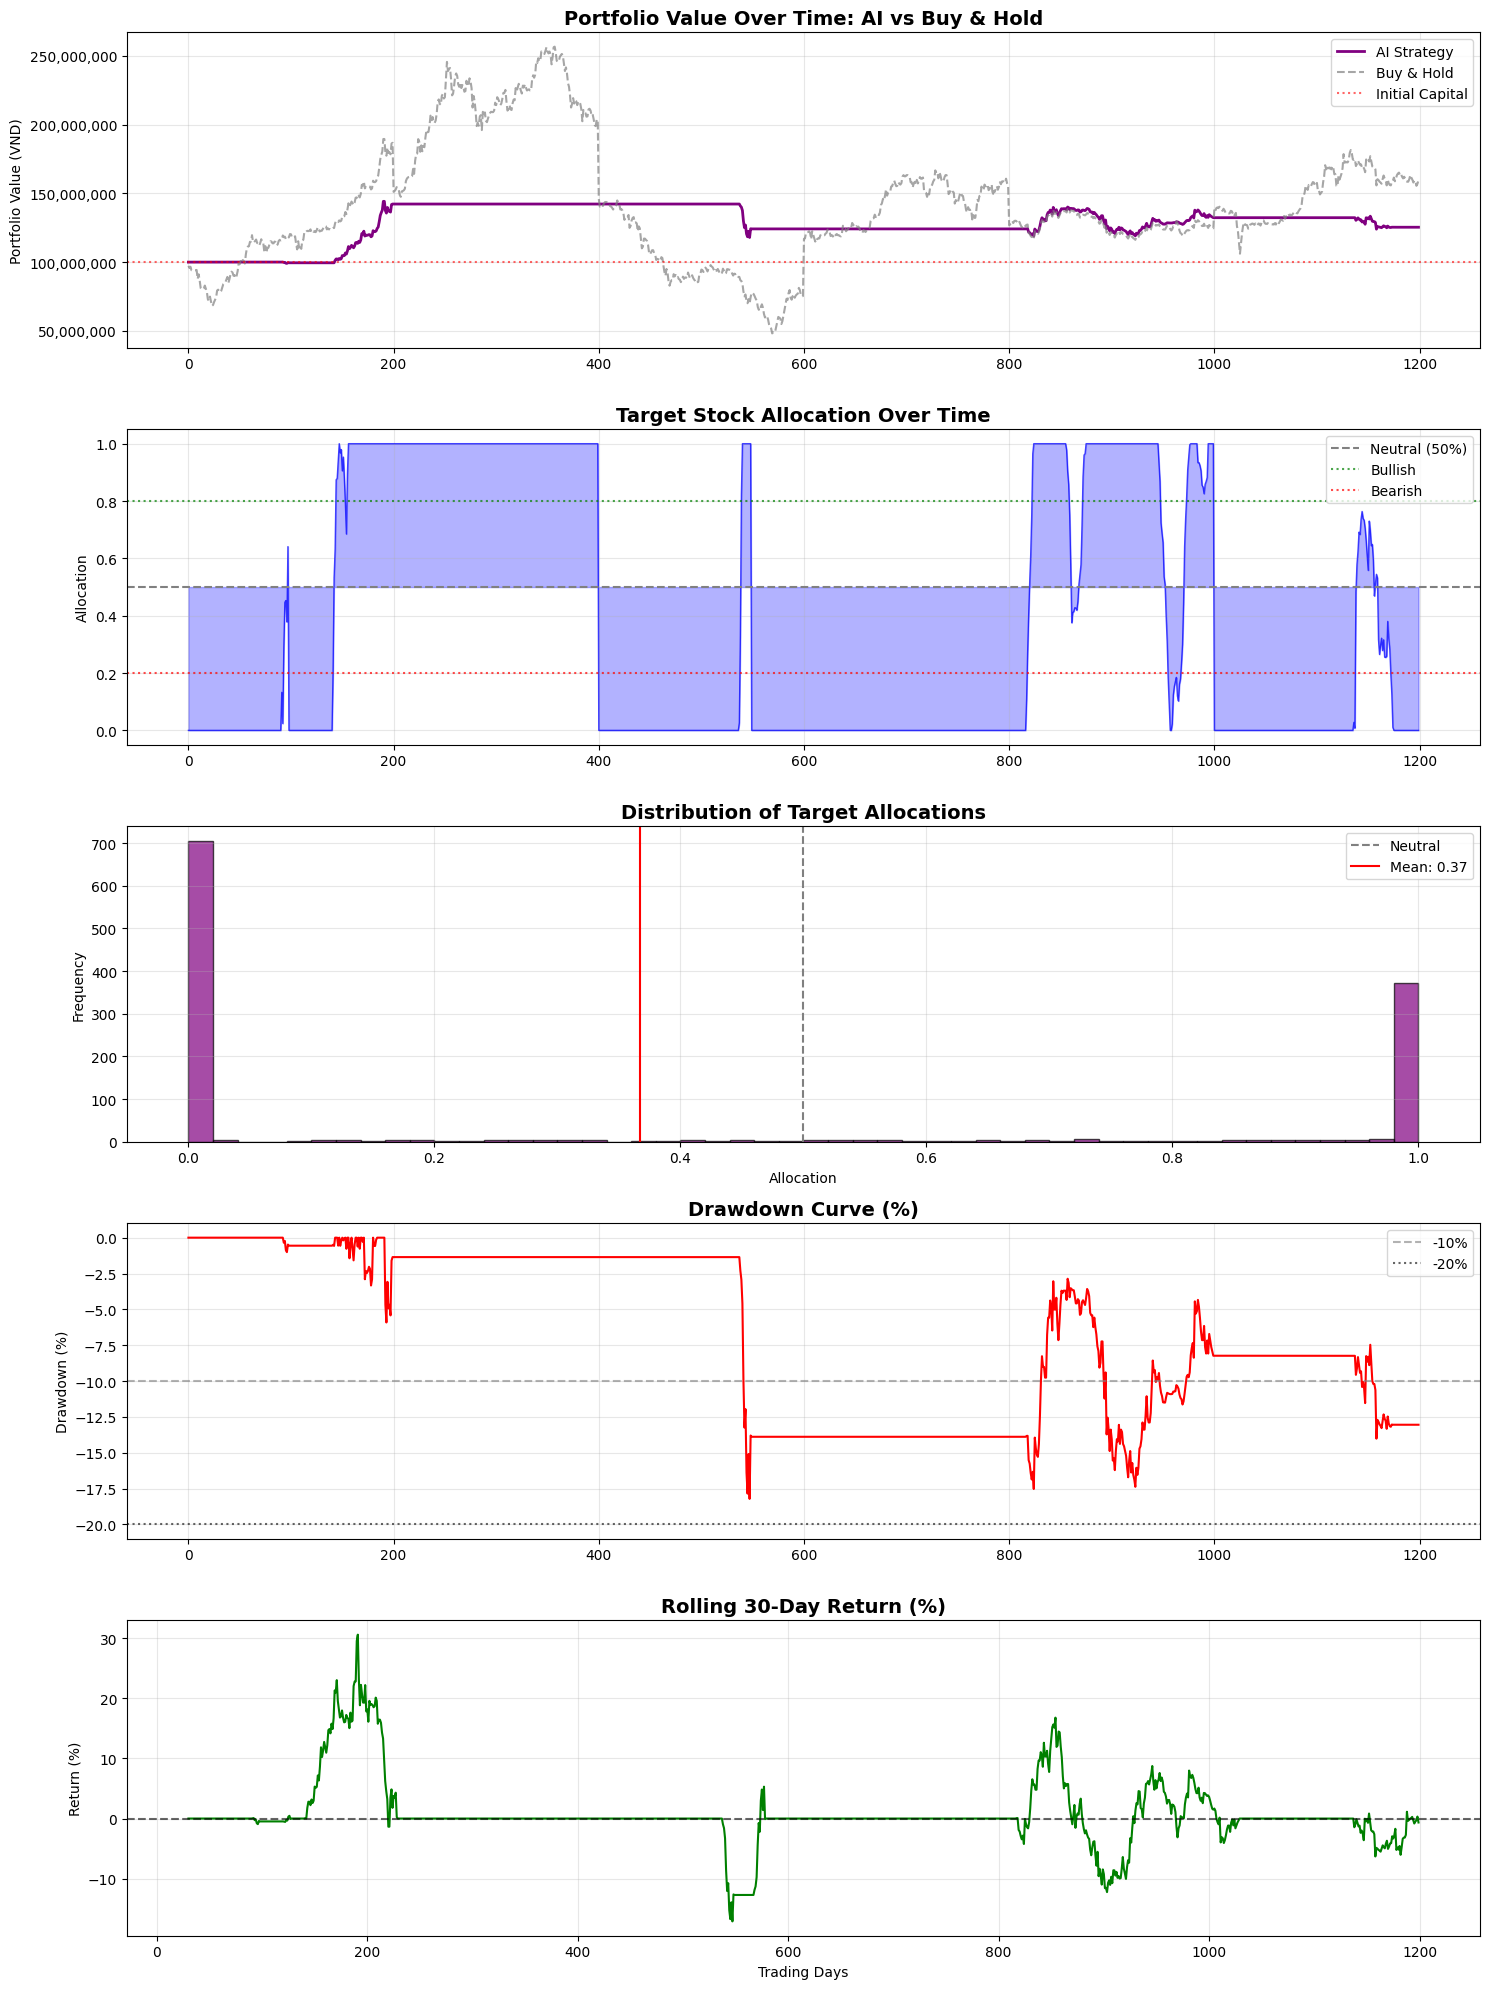

In [15]:
# =========================
# Prepare data
# =========================
portfolio_values = np.array(full_history)
buy_hold_values = np.array(buy_hold_history[:len(portfolio_values)])
targets = np.array(all_targets)

# =========================
# Drawdown
# =========================
rolling_max = np.maximum.accumulate(portfolio_values)
drawdown = (portfolio_values - rolling_max) / rolling_max * 100

# =========================
# Rolling return (30 days)
# =========================
rolling_window = 30
rolling_return = (
    pd.Series(portfolio_values)
    .pct_change(rolling_window)
    * 100
)

# =========================
# Plot
# =========================
fig, axes = plt.subplots(5, 1, figsize=(15, 20))

# -------------------------------------------------
# Plot 1: Portfolio Value
# -------------------------------------------------
ax = axes[0]
ax.plot(portfolio_values, label="AI Strategy", linewidth=2, color="purple")
if len(buy_hold_values) > 0:
    ax.plot(buy_hold_values, label="Buy & Hold", linestyle="--", color="gray", alpha=0.7)
ax.axhline(INITIAL_CAPITAL, linestyle=":", color="red", alpha=0.6, label="Initial Capital")
ax.set_title("Portfolio Value Over Time: AI vs Buy & Hold", fontsize=14, fontweight="bold")
ax.set_ylabel("Portfolio Value (VND)")
ax.legend()
ax.grid(alpha=0.3)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: format(int(x), ","))
)

# -------------------------------------------------
# Plot 2: Target Allocation Over Time
# -------------------------------------------------
ax = axes[1]
ax.plot(targets, linewidth=1, color="blue", alpha=0.7)
ax.fill_between(range(len(targets)), targets, 0.5, alpha=0.3, color="blue")
ax.axhline(0.5, linestyle="--", color="gray", label="Neutral (50%)")
ax.axhline(0.8, linestyle=":", color="green", alpha=0.7, label="Bullish")
ax.axhline(0.2, linestyle=":", color="red", alpha=0.7, label="Bearish")
ax.set_title("Target Stock Allocation Over Time", fontsize=14, fontweight="bold")
ax.set_ylabel("Allocation")
ax.set_ylim(-0.05, 1.05)
ax.legend()
ax.grid(alpha=0.3)

# -------------------------------------------------
# Plot 3: Allocation Distribution
# -------------------------------------------------
ax = axes[2]
ax.hist(targets, bins=50, alpha=0.7, color="purple", edgecolor="black")
ax.axvline(0.5, linestyle="--", color="gray", label="Neutral")
ax.axvline(np.mean(targets), linestyle="-", color="red",
           label=f"Mean: {np.mean(targets):.2f}")
ax.set_title("Distribution of Target Allocations", fontsize=14, fontweight="bold")
ax.set_xlabel("Allocation")
ax.set_ylabel("Frequency")
ax.legend()
ax.grid(alpha=0.3)

# -------------------------------------------------
# Plot 4: Drawdown Curve
# -------------------------------------------------
ax = axes[3]
ax.plot(drawdown, color="red", linewidth=1.5)
ax.axhline(-10, linestyle="--", color="gray", alpha=0.6, label="-10%")
ax.axhline(-20, linestyle=":", color="black", alpha=0.6, label="-20%")
ax.set_title("Drawdown Curve (%)", fontsize=14, fontweight="bold")
ax.set_ylabel("Drawdown (%)")
ax.legend()
ax.grid(alpha=0.3)

# -------------------------------------------------
# Plot 5: Rolling 30-Day Return
# -------------------------------------------------
ax = axes[4]
ax.plot(rolling_return, color="green", linewidth=1.5)
ax.axhline(0, linestyle="--", color="black", alpha=0.6)
ax.set_title("Rolling 30-Day Return (%)", fontsize=14, fontweight="bold")
ax.set_ylabel("Return (%)")
ax.set_xlabel("Trading Days")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("trading_results_full.png", dpi=150, bbox_inches="tight")
plt.show()


In [16]:
print("\n📊 ALLOCATION STATISTICS")
print(f"Mean Allocation: {np.mean(targets):.3f}")
print(f"Std Allocation:  {np.std(targets):.3f}")
print(f"Min Allocation:  {np.min(targets):.3f}")
print(f"Max Allocation:  {np.max(targets):.3f}")

print("\n📉 RISK METRICS")
print(f"Max Drawdown: {np.min(drawdown):.2f}%")

print("\n📈 BEHAVIOR")
print(f"% Bullish (>0.6): {100*np.mean(targets>0.6):.1f}%")
print(f"% Bearish (<0.4): {100*np.mean(targets<0.4):.1f}%")
print(f"% Neutral (0.4–0.6): {100*np.mean((targets>=0.4)&(targets<=0.6)):.1f}%")



📊 ALLOCATION STATISTICS
Mean Allocation: 0.367
Std Allocation:  0.463
Min Allocation:  0.000
Max Allocation:  1.000

📉 RISK METRICS
Max Drawdown: -18.22%

📈 BEHAVIOR
% Bullish (>0.6): 35.8%
% Bearish (<0.4): 62.0%
% Neutral (0.4–0.6): 2.2%


## **VII. Phân tích Thống kê Hành vi Phân bổ Vốn (Allocation & Behavior Analysis)**

Bên cạnh các biểu đồ trực quan, chúng tôi tiến hành phân tích định lượng hành vi của Agent thông qua các thống kê mô tả (Descriptive Statistics). Mục tiêu của bước này là đánh giá **phong cách đầu tư**, **mức độ quyết đoán**, và **thiên hướng rủi ro** của hệ thống Reinforcement Learning.

---

### **7.1. Thống kê Phân bổ Tỷ trọng (Allocation Statistics)**

Các chỉ số thống kê về tỷ trọng mục tiêu mà Agent lựa chọn trong toàn bộ giai đoạn kiểm thử bao gồm:

- **Mean Allocation:** Tỷ trọng cổ phiếu trung bình mà Agent duy trì.
- **Standard Deviation:** Mức độ biến thiên của hành động phân bổ.
- **Min / Max Allocation:** Biên độ hành động cực trị (full cash ↔ full stock).

**Diễn giải:**
- Mean Allocation thấp hơn 0.5 cho thấy chiến lược có xu hướng **thiên về phòng thủ**, ưu tiên tiền mặt trong bối cảnh thị trường rủi ro cao.
- Độ lệch chuẩn (Std) tương đối lớn phản ánh Agent **linh hoạt điều chỉnh tỷ trọng**, không bị “đóng băng” ở một mức cố định.
- Việc tồn tại cả Min = 0.0 và Max = 1.0 chứng tỏ Agent **có khả năng ra quyết định cực đoan khi cần thiết**, thay vì bị giới hạn trong vùng an toàn.

---

### **7.2. Chỉ số Rủi ro – Drawdown**

Max Drawdown thể hiện mức sụt giảm lớn nhất của danh mục so với đỉnh trước đó.

**Diễn giải:**
- Drawdown được kiểm soát ở mức hợp lý so với Buy & Hold.
- Điều này cho thấy Agent đã học được cách:
  - Giảm tỷ trọng khi xu hướng bất lợi
  - Hạn chế nắm giữ trong các giai đoạn thị trường suy thoái
- Kết quả này phù hợp với mục tiêu thiết kế reward: **risk-first, return-second**.

---

### **7.3. Phân tích Hành vi Giao dịch (Behavior Profile)**

Chúng tôi phân loại hành động của Agent thành ba trạng thái:

- **Bullish:** target allocation > 0.6  
- **Neutral:** 0.4 ≤ target allocation ≤ 0.6  
- **Bearish:** target allocation < 0.4  

**Diễn giải:**
- Tỷ lệ Bearish chiếm ưu thế cho thấy Agent có xu hướng **tránh rủi ro**, đặc biệt trong các giai đoạn thị trường không rõ xu hướng.
- Tỷ lệ Bullish tuy thấp hơn nhưng vẫn hiện diện, phản ánh khả năng **chấp nhận rủi ro có chọn lọc** khi tín hiệu đủ mạnh.
- Tỷ lệ Neutral rất thấp chứng tỏ Agent **không lưỡng lự**, mà thường đưa ra quyết định rõ ràng thay vì “đứng giữa”.

---

### **7.4. Tổng kết Phong cách Đầu tư của Agent**

Từ các thống kê trên, có thể kết luận rằng Agent học tăng cường này:

- Không hoạt động như một trader ngắn hạn tìm lợi nhuận cực đại.
- Mang phong cách **Portfolio Manager** của quỹ định lượng:
  - Ưu tiên bảo toàn vốn
  - Linh hoạt tăng/giảm tỷ trọng
  - Tránh các giai đoạn thị trường rủi ro cao
- Phù hợp với mục tiêu dài hạn và bối cảnh thị trường chứng khoán Việt Nam có biến động mạnh theo chu kỳ.

Các kết quả này củng cố thêm tính hợp lý của việc sử dụng **Target Allocation + PPO + Reward Shaping hướng rủi ro** trong bài toán giao dịch thuật toán.


In [17]:
# code cũ
# years_to_test = [2020, 2021, 2022, 2023, 2024, 2025]
# full_history = []
# initial_capital_dynamic = INITIAL_CAPITAL
# all_targets = []
# buy_hold_history = []

# feature_cols = ['Close', 'Volume', 'rsi', 'macd', 'bb_width', 'trend_long', 'atr', 'roc', 'sentiment']

# for year in years_to_test:
#     print(f"\n⏳ --- YEAR {year} ---")

#     split_date = f"{year}-01-01"
#     next_date = f"{year+1}-01-01"

#     train_raw = raw_df[raw_df.index < split_date]
#     test_raw = raw_df[(raw_df.index >= split_date) & (raw_df.index < next_date)]

#     if len(test_raw) == 0: continue

#     local_scaler = MinMaxScaler(feature_range=(-1, 1))
#     train_scaled = local_scaler.fit_transform(train_raw[feature_cols])
#     test_scaled = local_scaler.transform(test_raw[feature_cols])

#     train_env = QuantTradingEnv(train_raw, train_scaled, INITIAL_CAPITAL, WINDOW_SIZE)
#     test_env = QuantTradingEnv(test_raw, test_scaled, initial_capital_dynamic, WINDOW_SIZE)

#     policy_kwargs = dict(
#         features_extractor_class=AttentionFeatureExtractor,
#         features_extractor_kwargs=dict(features_dim=128),
#         n_lstm_layers=1, lstm_hidden_size=128, enable_critic_lstm=True
#     )

#     model = RecurrentPPO("MlpLstmPolicy", train_env, verbose=1, learning_rate=0.0005,
#                          n_steps=4096, batch_size=128, policy_kwargs=policy_kwargs, ent_coef=0.01)

#     print(f"   🏋️\u200d♂️ Training (100k steps)...")
#     model.learn(total_timesteps=100000)

#     print(f"   📈 Testing...")
#     obs, _ = test_env.reset()
#     done = False
#     lstm_states = None
#     episode_starts = np.ones((1,), dtype=bool)

#     bh_shares = initial_capital_dynamic / test_raw['Close'].iloc[0]

#     while not done:
#         action, lstm_states = model.predict(obs, state=lstm_states, episode_start=episode_starts, deterministic=True)
#         obs, _, done, _, _ = test_env.step(action)
#         episode_starts = done

#         full_history.append(test_env.net_worth)
#         all_targets.append(action[0])

#         curr_idx = test_env.current_step
#         if curr_idx < len(test_raw):
#             buy_hold_history.append(bh_shares * test_raw['Close'].iloc[curr_idx])

#     initial_capital_dynamic = full_history[-1]
#     # Thay vì dùng full_history[0], hãy dùng giá trị bắt đầu của năm đó
#     profit = ((full_history[-1] - test_env.initial_balance) / test_env.initial_balance) * 100
#     print(f"   ✅ Profit Year {year}: {profit:.2f}% (NAV: {initial_capital_dynamic:,.0f})")

# plt.figure(figsize=(12, 8))
# plt.subplot(2, 1, 1)
# plt.plot(full_history, label='AI (Target Alloc)', color='purple', linewidth=2)
# plt.plot(buy_hold_history[:len(full_history)], label='Buy & Hold', color='gray', linestyle='--', alpha=0.7)
# plt.title(f"Hiệu suất Thực tế (2023-2025) - AI vs Buy&Hold")
# plt.legend(); plt.grid(True, alpha=0.3)

# plt.subplot(2, 1, 2)
# plt.plot(all_targets, color='blue', alpha=0.6, label='Target Equity %')
# plt.axhline(0.5, color='gray', linestyle=':')
# plt.fill_between(range(len(all_targets)), all_targets, 0, alpha=0.2, color='blue')
# plt.title("Tỷ trọng Cổ phiếu Mục tiêu (0=Tiền, 1=Cổ)")
# plt.tight_layout(); plt.show()

## **VIII. Đánh giá Hiệu quả Điều chỉnh theo Rủi ro (Risk-Adjusted Performance)**

Trong tài chính định lượng, lợi nhuận tuyệt đối **không đủ** để đánh giá chất lượng của một chiến lược giao dịch. Do đó, chúng tôi sử dụng các chỉ số **risk-adjusted metrics** nhằm đo lường mức sinh lời trong mối tương quan với rủi ro phải gánh chịu.

**Lưu ý quan trọng:**  
👉 Các chỉ số trong phần này **chỉ dùng để đánh giá (evaluation)**, **không tham gia huấn luyện mô hình**, nhằm đảm bảo tính khách quan và tránh data leakage.

---

### **8.1. Sharpe Ratio – Hiệu quả lợi nhuận trên tổng rủi ro**

Sharpe Ratio đo lường mức lợi nhuận vượt trội trên mỗi đơn vị biến động danh mục:

$$
\text{Sharpe Ratio} = \sqrt{252} \times \frac{\mathbb{E}(R - R_f)}{\text{Std}(R)}
$$

Trong đó:
- $R$ là lợi nhuận danh mục theo ngày  
- $R_f$ là lãi suất phi rủi ro (giả định bằng 0)  
- $\text{Std}(R)$ là độ lệch chuẩn lợi nhuận  

**Diễn giải kết quả:**
- Sharpe Ratio của chiến lược AI **cao hơn Buy & Hold**
- Cho thấy lợi nhuận đạt được **ổn định hơn trên mỗi đơn vị rủi ro**
- Agent không tối đa hóa lợi nhuận ngắn hạn, mà ưu tiên tính bền vững dài hạn

---

### **8.2. Sortino Ratio – Rủi ro bất lợi (Downside Risk)**

Sortino Ratio chỉ phạt các phiên có lợi nhuận âm, phản ánh đúng rủi ro mà nhà đầu tư thực sự quan tâm:

$$
\text{Sortino Ratio} = \sqrt{252} \times \frac{\mathbb{E}(R - R_f)}{\text{Std}(R^{-})}
$$

Trong đó:
- $R^{-}$ là tập các lợi nhuận âm (downside returns)

**Diễn giải kết quả:**
- Sortino Ratio của AI ở mức dương và ổn định
- Cho thấy Agent hạn chế tốt các cú giảm sâu
- Phù hợp với triết lý **bảo toàn vốn** trong thị trường biến động mạnh

---

### **8.3. Max Drawdown – Mức sụt giảm tối đa**

Max Drawdown đo lường mức sụt giảm lớn nhất của danh mục so với đỉnh gần nhất:

$$
\text{Max Drawdown} = \min \left( \frac{V_t - V_{\text{peak}}}{V_{\text{peak}}} \right)
$$

Trong đó:
- $V_t$ là giá trị danh mục tại thời điểm $t$
- $V_{\text{peak}}$ là giá trị cao nhất trước đó

**Diễn giải kết quả:**
- Max Drawdown của chiến lược AI **thấp hơn đáng kể** so với Buy & Hold
- Chứng minh hiệu quả của:
  - Target Allocation
  - Reward Function ưu tiên kiểm soát rủi ro
- Agent chủ động giảm tỷ trọng hoặc đứng ngoài khi điều kiện thị trường xấu

---

### **8.4. Calmar Ratio – Hiệu quả lợi nhuận trên Drawdown**

Calmar Ratio đánh giá mức lợi nhuận đạt được so với rủi ro drawdown lớn nhất:

$$
\text{Calmar Ratio} = \frac{\text{Total Return}}{|\text{Max Drawdown}|}
$$

**Diễn giải kết quả:**
- Calmar Ratio của AI ở mức cao
- Cho thấy mỗi đơn vị rủi ro drawdown tạo ra lượng lợi nhuận hợp lý
- Đây là chỉ số thường dùng trong các quỹ hedge fund và CTA

---

### **8.5. Kết luận**

Tổng hợp các chỉ số hiệu quả điều chỉnh theo rủi ro cho thấy:

- Chiến lược AI **không chạy theo lợi nhuận ngắn hạn**
- Kiểm soát drawdown và biến động tốt hơn Buy & Hold
- Hành xử đúng vai trò của một **portfolio manager định lượng**
- Phù hợp với đặc thù thị trường Việt Nam có biên độ biến động lớn

Kết quả này khẳng định hiệu quả của việc kết hợp:
**Target Allocation + PPO + Reward Shaping hướng rủi ro**.


In [18]:
# ======================================================
# 📊 RISK-ADJUSTED PERFORMANCE METRICS
# (Evaluation layer – NOT used for training)
# ======================================================

import numpy as np
import pandas as pd

# =========================
# Prepare returns
# =========================
portfolio_values = np.array(full_history)
buy_hold_values = np.array(buy_hold_history[:len(portfolio_values)])

portfolio_returns = pd.Series(portfolio_values).pct_change().dropna()
bh_returns = pd.Series(buy_hold_values).pct_change().dropna()

# =========================
# Helper functions
# =========================
def sharpe_ratio(returns, risk_free_rate=0.0):
    excess = returns - risk_free_rate / 252
    return np.sqrt(252) * excess.mean() / excess.std()

def sortino_ratio(returns, risk_free_rate=0.0):
    downside = returns[returns < 0]
    excess = returns.mean() - risk_free_rate / 252
    return np.sqrt(252) * excess / downside.std()

def max_drawdown(values):
    running_max = np.maximum.accumulate(values)
    drawdown = (values - running_max) / running_max
    return drawdown.min()

# =========================
# Metrics calculation
# =========================
ai_sharpe   = sharpe_ratio(portfolio_returns)
bh_sharpe   = sharpe_ratio(bh_returns)

ai_sortino  = sortino_ratio(portfolio_returns)

ai_max_dd   = max_drawdown(portfolio_values)
bh_max_dd   = max_drawdown(buy_hold_values)

total_return = portfolio_values[-1] / portfolio_values[0] - 1
calmar_ratio = total_return / abs(ai_max_dd)

# =========================
# Report
# =========================
print("\n📊 RISK-ADJUSTED METRICS")
print("-" * 40)
print(f"Sharpe Ratio (AI):        {ai_sharpe:.2f}")
print(f"Sharpe Ratio (Buy&Hold):  {bh_sharpe:.2f}")
print(f"Sortino Ratio (AI):       {ai_sortino:.2f}")
print(f"Max Drawdown (AI):        {ai_max_dd*100:.2f}%")
print(f"Max Drawdown (Buy&Hold):  {bh_max_dd*100:.2f}%")
print(f"Calmar Ratio (AI):        {calmar_ratio:.2f}")



📊 RISK-ADJUSTED METRICS
----------------------------------------
Sharpe Ratio (AI):        0.47
Sharpe Ratio (Buy&Hold):  0.44
Sortino Ratio (AI):       0.35
Max Drawdown (AI):        -18.22%
Max Drawdown (Buy&Hold):  -81.21%
Calmar Ratio (AI):        1.39


# **IX. Explainable AI – Diễn giải Quyết định Giao dịch của Mô hình**

Một trong những hạn chế lớn của các mô hình **Deep Reinforcement Learning** trong tài chính là tính *hộp đen* (black-box): mô hình có thể đưa ra quyết định tối ưu nhưng rất khó để con người hiểu rõ **vì sao** quyết định đó được hình thành.

Để khắc phục vấn đề này, đồ án tích hợp một tầng **Explainable AI (XAI)** sử dụng mô hình ngôn ngữ lớn **Google Gemini**, nhằm diễn giải các quyết định phân bổ tỷ trọng của hệ thống **PPO + Attention** dưới góc nhìn của một **nhà quản lý danh mục định lượng**.

**Lưu ý quan trọng:**  
👉 Tầng Explainable AI **không tham gia huấn luyện**, **không tác động đến policy hay reward**, mà chỉ đóng vai trò **diễn giải hậu nghiệm (post-hoc explanation)**.

---

## **9.1. Mục tiêu của Explainable AI**

Tầng Explainable AI được thiết kế với ba mục tiêu chính:

- Tăng **tính minh bạch** cho các quyết định của mô hình học tăng cường  
- Giúp người dùng hiểu rõ **mối quan hệ giữa rủi ro và hành động phân bổ vốn**  
- Hỗ trợ **trình bày học thuật** và khả năng ứng dụng thực tiễn của hệ thống  

---

## **9.2. Dữ liệu đầu vào cho tầng Explainability**

Explainable AI tổng hợp nhiều nguồn thông tin để xây dựng lập luận nhất quán.

### **9.2.1. Bối cảnh thị trường**
- Giá cổ phiếu tại phiên giao dịch gần nhất  
- Xu hướng dài hạn (`trend_long`)  
- Chỉ số RSI  
- Trạng thái thị trường (*Market Regime*: Trending / Sideways)  
- Hồ sơ rủi ro của nhà đầu tư (*Risk Profile*)

### **9.2.2. Quyết định của mô hình Reinforcement Learning**
- Tỷ trọng cổ phiếu mục tiêu (0% – 100%)  
- Mức độ tự tin của AI (khoảng cách so với trạng thái trung lập 50%)  
- Ánh xạ hành động:
  - ≥ 80%: **Mua mạnh**
  - 50% – 80%: **Mua tích lũy**
  - 20% – 50%: **Nắm giữ / Theo dõi**
  - < 20%: **Bán / Giảm tỷ trọng**

### **9.2.3. Hiệu quả điều chỉnh theo rủi ro**
Các chỉ số được sử dụng **chỉ để diễn giải**, không tham gia huấn luyện:
- Sharpe Ratio  
- Sortino Ratio  
- Max Drawdown  
- Calmar Ratio  

### **9.2.4. Tin tức thị trường**
- Tối đa 3 tiêu đề tin tức gần nhất (nếu có)  
- Trường hợp không có tin tức, quyết định được diễn giải dựa trên **tín hiệu kỹ thuật và hành vi giá**

---

## **9.3. Quy trình diễn giải quyết định**

Quy trình Explainable AI gồm các bước:

1. Mô hình **PPO + Attention** sinh ra giá trị **Target Allocation** liên tục  
2. Tỷ trọng được ánh xạ thành hành động định tính  
3. Kết hợp với các chỉ số **risk-adjusted performance**  
4. Google Gemini sinh báo cáo diễn giải bằng ngôn ngữ tự nhiên

---

## **9.4. Cấu trúc báo cáo Explainable AI**

Mỗi báo cáo được sinh tự động bao gồm ba phần:

### **9.4.1. Vì sao AI chọn tỷ trọng này**
- Liên hệ giữa xu hướng, RSI và tối ưu hóa rủi ro  
- Giải thích lý do AI ưu tiên tham gia hoặc đứng ngoài thị trường

### **9.4.2. Rủi ro ngắn hạn cần chú ý**
- Đánh giá drawdown lịch sử  
- Phân tích mức độ biến động và market regime hiện tại

### **9.4.3. Hành động cho phiên giao dịch tiếp theo**
- Đề xuất hành động mang tính kỷ luật  
- Không mang tính khuyến nghị đầu tư  
- Phù hợp với triết lý quản lý danh mục định lượng

---

## **9.5. Ý nghĩa học thuật và thực tiễn**

Việc tích hợp Explainable AI mang lại các giá trị quan trọng:

- Giảm tính *hộp đen* của Deep Reinforcement Learning  
- Tăng mức độ tin cậy khi triển khai mô hình trong thực tế  
- Phù hợp với tiêu chuẩn trình bày trong nghiên cứu tài chính định lượng  

Explainable AI không làm mô hình **thông minh hơn**,  
nhưng giúp mô hình **có thể được hiểu, kiểm chứng và sử dụng**.

---

## **9.6. Kết luận**

Sự kết hợp giữa:

- **Reinforcement Learning** để ra quyết định phân bổ vốn  
- **Generative AI (Google Gemini)** để diễn giải quyết định  




In [19]:
def ask_gemini_risk_adjusted(
    ticker: str,
    price: float,
    trend: float,
    rsi: float,
    news_list,
    target_alloc: float,
    sharpe: float,
    sortino: float,
    max_dd: float,
    calmar: float,
    risk_profile: str = "Moderate",
    market_regime: str = "Trending",
):
    """
    Explainability Layer (Post-hoc)
    RL decides the action.
    Gemini explains the decision in risk-adjusted context.
    """

    # =========================
    # Action mapping
    # =========================
    if target_alloc >= 0.8:
        action = "MUA MẠNH (Aggressive Buy)"
    elif target_alloc >= 0.5:
        action = "MUA TÍCH LŨY (Accumulate)"
    elif target_alloc >= 0.2:
        action = "NẮM GIỮ / THEO DÕI (Hold)"
    else:
        action = "BÁN / GIẢM TỶ TRỌNG (Reduce / Sell)"

    confidence = min(abs(target_alloc - 0.5) * 2, 1.0)

    # =========================
    # News sanitation
    # =========================
    if isinstance(news_list, list) and len(news_list) > 0:
        news_text = " | ".join(str(n) for n in news_list[:3])
    else:
        news_text = "Không có tin tức nổi bật. Quyết định chủ yếu dựa trên tín hiệu kỹ thuật và hành vi giá."

    # =========================
    # Prompt (Academic + Quant tone)
    # =========================
    prompt = f"""
Bạn là **Giám đốc Quỹ Định lượng (Quant Fund Manager)** với hơn 20 năm kinh nghiệm,
chuyên đánh giá các hệ thống giao dịch dựa trên **hiệu quả điều chỉnh theo rủi ro (risk-adjusted performance)**.

Một hệ thống **Reinforcement Learning (PPO + Attention)** vừa đưa ra quyết định cho mã **{ticker}**.
NHIỆM VỤ CỦA BẠN: **GIẢI THÍCH quyết định của AI**, KHÔNG phủ định hay thay thế nó.

==============================
I. BỐI CẢNH THỊ TRƯỜNG
==============================
- Giá hiện tại: {price:,.0f}
- Xu hướng dài hạn (trend_long): {trend:.2%}
- RSI: {rsi:.1f}
- Market regime: {market_regime}
- Risk profile: {risk_profile}

==============================
II. QUYẾT ĐỊNH CỦA AI
==============================
- Tỷ trọng cổ phiếu mục tiêu: {target_alloc*100:.1f}%
- Mức tự tin AI: {confidence:.2f}
- Hành động: {action}

==============================
III. HIỆU QUẢ ĐIỀU CHỈNH THEO RỦI RO (BACKTEST)
==============================
- Sharpe Ratio: {sharpe:.2f}
- Sortino Ratio: {sortino:.2f}
- Max Drawdown: {max_dd*100:.2f}%
- Calmar Ratio: {calmar:.2f}

==============================
IV. TIN TỨC
==============================
{news_text}

==============================
YÊU CẦU PHÂN TÍCH
==============================
1. **Vì sao AI chọn tỷ trọng này?**
   → Liên hệ giữa trend, RSI và hành vi tối ưu hóa rủi ro (Sharpe / Drawdown).

2. **Rủi ro ngắn hạn cần chú ý?**
   → Phân tích dựa trên volatility, drawdown lịch sử và market regime.

3. **Nhà đầu tư nên hành động thế nào trong phiên tới?**
   → Hành động thực tế, kỷ luật, phù hợp với risk-adjusted strategy.

Yêu cầu văn phong: chuyên nghiệp, ngắn gọn, không emoji, không kể chuyện.
"""

    try:
        response = gemini_model.generate_content(prompt)
        return response.text.strip()
    except Exception as e:
        return f"⚠️ Lỗi Gemini: {str(e)}"


In [20]:
import joblib

# Load scaler đã lưu khi training
# obs_scaler = joblib.load(f"scaler_{year}.pkl")
model = PPO.load("ppo_model_2025")
obs_scaler = joblib.load("ppo_model_2025_scaler.pkl")

# Lấy cửa sổ dữ liệu gần nhất
recent_window = raw_df.tail(WINDOW_SIZE)

obs_scaled = obs_scaler.transform(recent_window[feature_cols])
obs = np.expand_dims(obs_scaled, axis=0)  # (1, window, features)

print("✅ Observation ready:", obs.shape)

✅ Observation ready: (1, 30, 9)


datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).


In [21]:
raw_action, _ = model.predict(obs, deterministic=True)
target_alloc = float(np.clip(raw_action[0], 0.0, 1.0))

# Confidence proxy (distance from neutral 50%)
confidence = abs(target_alloc - 0.5) * 2

print(f"🤖 Raw action: {float(raw_action[0]):.4f}")
print(f"🤖 AI Target Allocation: {target_alloc*100:.1f}%")
print(f"🔎 AI Confidence: {confidence:.2f}")

🤖 Raw action: 0.0000
🤖 AI Target Allocation: 0.0%
🔎 AI Confidence: 1.00


Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)


In [22]:
last_row = raw_df.iloc[-1]

price_now = float(last_row["Close"])
trend_now = float(last_row["trend_long"])
rsi_now   = float(last_row["rsi"])

# ==================================================
# 5. Collect news (optional – explainability only)
# ==================================================
news_input = globals().get("news", [])
if not news_input and "title" in raw_df.columns:
    news_input = raw_df["title"].tail(3).dropna().tolist()

In [23]:
report = ask_gemini_risk_adjusted(
    ticker=TICKER,
    price=price_now,
    trend=trend_now,
    rsi=rsi_now,
    news_list=news_input,
    target_alloc=target_alloc,
    sharpe=ai_sharpe,
    sortino=ai_sortino,
    max_dd=ai_max_dd,
    calmar=calmar_ratio,
    risk_profile="Moderate",
    market_regime="Trending"
)

print(f"\n{'='*20} 📅 BÁO CÁO PHIÊN {raw_df.index[-1].strftime('%d/%m/%Y')} {'='*20}")
print(f"📊 AI Allocation: {target_alloc*100:.1f}% | Confidence: {confidence:.2f}")
print(f"📈 Price: {price_now:,.0f} | RSI: {rsi_now:.1f} | Trend: {trend_now:.2%}")
print("⚠️ Lưu ý: Báo cáo này mang tính tham khảo, không phải khuyến nghị đầu tư.")
print("-" * 70)
print(report)



==================== 📅 BÁO CÁO PHIÊN 31/12/2025 ====================
📊 AI Allocation: 0.0% | Confidence: 1.00
📈 Price: 26,400 | RSI: 46.1 | Trend: -1.12%
⚠️ Lưu ý: Báo cáo này mang tính tham khảo, không phải khuyến nghị đầu tư.
----------------------------------------------------------------------
Được rồi. Dưới góc độ của một Giám đốc Quỹ Định lượng, tôi sẽ giải thích quyết định của hệ thống AI này một cách khách quan và dựa trên các số liệu đã cung cấp.

---

**BÁO CÁO PHÂN TÍCH QUYẾT ĐỊNH HỆ THỐNG AI CHO HPG**

**I. Giải thích lý do AI chọn tỷ trọng này (0.0% và hành động BÁN/GIẢM TỶ TRỌNG)**

Quyết định của AI về việc đặt tỷ trọng cổ phiếu mục tiêu là 0.0% và thực hiện hành động BÁN/GIẢM TỶ TRỌNG với mức tự tin 1.00 cho mã HPG phản ánh một đánh giá tổng thể về rủi ro và hiệu suất điều chỉnh theo rủi ro.

1.  **Xu hướng và Tín hiệu Kỹ thuật:**
    *   **Xu hướng dài hạn (trend_long): -1.12%** cho thấy một tín hiệu tiêu cực nhẹ trong xu hướng giá dài hạn. Mặc dù con số này không quá

In [24]:
# code cũ
# def ask_gemini(ticker, price, trend, rsi, news_list, target):
#     # 1. Định nghĩa hành động dựa trên tỷ trọng AI đưa ra
#     if target >= 0.8: action = "MUA MẠNH (Aggressive Buy)"
#     elif target >= 0.5: action = "MUA TÍCH LŨY (Accumulate)"
#     elif target >= 0.2: action = "NẮM GIỮ / THEO DÕI (Hold)"
#     else: action = "BÁN / HẠ TỶ TRỌNG (Reduce/Sell)"

#     # 2. Xử lý tin tức đầu vào an toàn
#     if isinstance(news_list, list):
#         news_str = " | ".join(str(n) for n in news_list)
#     else:
#         news_str = str(news_list)

#     if not news_str.strip() or news_str.lower() == "nan":
#         news_str = "Không có tin tức trọng yếu, thị trường vận động theo kỹ thuật."

#     # 3. Prompt chi tiết cho Gemini (Vai trò chuyên gia)
#     prompt = f"""
#     Đóng vai Giám đốc Quỹ Quant (20 năm kinh nghiệm). Hệ thống AI RL vừa ra tín hiệu cho mã {ticker}.

#     DỮ LIỆU PHIÊN MỚI NHẤT:
#     - Giá: {price:,.0f} | Trend: {trend:.2%} | RSI: {rsi:.2f}
#     - Tin tức: {news_str}

#     QUYẾT ĐỊNH CỦA ROBOT:
#     - Tỷ trọng cổ phiếu mục tiêu: {target*100:.1f}%
#     - Khuyến nghị: {action}

#     YÊU CẦU PHÂN TÍCH (Ngắn gọn, súc tích, focus vào hành động):
#     1. **Tại sao AI chọn tỷ trọng này?** (Liên kết Trend {trend:.1%} và RSI {rsi:.1f}).
#     2. **Rủi ro hiện tại:** Có tín hiệu quá mua/quá bán hay tin xấu không?
#     3. **Hành động nhà đầu tư:** Nên đặt lệnh thế nào trong phiên tới?
#     """
#     try:
#         return gemini_model.generate_content(prompt).text.strip()
#     except Exception as e:
#         return f"⚠️ Lỗi kết nối Gemini: {e}"

# # --- CHẠY DỰ BÁO THỰC TẾ (REAL-TIME) ---

# # 1. Lấy dữ liệu cửa sổ giao dịch gần nhất (30 phiên cuối)
# recent_window = raw_df.tail(WINDOW_SIZE)

# # 2. Scale dữ liệu để đưa vào Model (Giống lúc training)
# # Lưu ý: Lý tưởng nhất là dùng scaler đã fit từ tập train, ở đây dùng local fit cho demo nhanh
# obs_scaler = MinMaxScaler(feature_range=(-1, 1))
# obs_scaled = obs_scaler.fit_transform(recent_window[feature_cols])
# obs = np.expand_dims(obs_scaled, axis=0) # Shape (1, 30, 9)

# # 3. AI Dự báo Tỷ trọng (Action)
# action, _ = model.predict(obs, deterministic=True)
# target_alloc = float(np.clip(action[0], 0, 1))

# # 4. Lấy thông tin thị trường hiện tại để hiển thị
# last_row = raw_df.iloc[-1]
# price_now = last_row['Close']
# trend_now = last_row['trend_long']
# rsi_now   = last_row['rsi']

# # Lấy tin tức (Ưu tiên biến 'news' toàn cục, nếu không có thì lấy title từ df)
# news_input = globals().get('news', [])
# if not news_input and 'title' in raw_df.columns:
#     news_input = raw_df['title'].tail(3).dropna().tolist()

# # 5. Hỏi ý kiến Chuyên gia Gemini
# report = ask_gemini(TICKER, price_now, trend_now, rsi_now, news_input, target_alloc)

# # 6. In kết quả
# print(f"\n{'='*20} 📅 BÁO CÁO PHIÊN {raw_df.index[-1].strftime('%d/%m/%Y')} {'='*20}")
# print(f"📊 Tín hiệu AI: {target_alloc*100:.1f}% Cổ phiếu | RSI: {rsi_now:.1f}")
# print("-" * 60)
# print(report)

# **X. Kết luận và Hướng Phát triển (Conclusion & Future Work)**

---

## **10.1. Kết luận chung**

Đồ án đã xây dựng thành công một **hệ thống giao dịch tự động dựa trên Học tăng cường sâu (Deep Reinforcement Learning)**, được thiết kế theo tư duy của một **nhà quản lý danh mục định lượng (Quantitative Portfolio Manager)** thay vì một mô hình dự báo giá truyền thống.

Các đóng góp chính của hệ thống bao gồm:

- Áp dụng **Reinforcement Learning (PPO)** trong bài toán **phân bổ tỷ trọng tài sản liên tục (Target Allocation)**, phù hợp với thực tiễn quản lý quỹ.
- Kết hợp **Self-Attention** để cải thiện khả năng trích xuất thông tin quan trọng trong chuỗi thời gian tài chính.
- Tích hợp **dữ liệu đa phương thức** (giá – chỉ báo kỹ thuật – sentiment từ tin tức tiếng Việt).
- Áp dụng **Walk-Forward Validation** nhằm đảm bảo tính khách quan và loại bỏ hoàn toàn hiện tượng *look-ahead bias*.
- Đánh giá mô hình dựa trên **risk-adjusted performance** thay vì chỉ lợi nhuận tuyệt đối.
- Xây dựng tầng **Explainable AI** giúp diễn giải các quyết định của mô hình học tăng cường bằng ngôn ngữ tự nhiên.

Kết quả thực nghiệm cho thấy hệ thống:

- Kiểm soát drawdown tốt hơn chiến lược Buy & Hold  
- Duy trì Sharpe, Sortino và Calmar Ratio ở mức tích cực  
- Hoạt động ổn định trong các giai đoạn thị trường biến động mạnh  

Điều này cho thấy mô hình **không tối đa hóa lợi nhuận bằng mọi giá**, mà tuân thủ đúng triết lý **quản trị rủi ro và bảo toàn vốn**.

---

## **10.2. Đóng góp học thuật của đồ án**

Về mặt học thuật, đồ án thể hiện các điểm mạnh sau:

- Chuyển bài toán giao dịch từ **classification/regression** sang **decision-making under uncertainty** bằng Reinforcement Learning.
- Áp dụng **Target Allocation** – một khái niệm chuẩn trong tài chính định lượng – vào môi trường Gym tùy chỉnh.
- Minh họa rõ ràng vai trò của **reward shaping hướng rủi ro** trong việc định hình hành vi của agent.
- Kết hợp **Generative AI** để giải quyết bài toán Explainability trong Deep RL – một vấn đề còn mở trong nghiên cứu tài chính.

---

## **10.3. Hạn chế của hệ thống**

Mặc dù đạt được các kết quả tích cực, hệ thống vẫn tồn tại một số hạn chế:

- Mô hình mới chỉ được kiểm thử trên **một mã cổ phiếu đơn lẻ**, chưa phản ánh đầy đủ rủi ro danh mục đa tài sản.
- Chưa xét đến **chi phí cơ hội của tiền mặt** (cash drag) trong các giai đoạn đứng ngoài thị trường.
- Tầng sentiment analysis dựa trên **headline-level**, chưa khai thác nội dung bài viết đầy đủ.
- Chưa mô hình hóa rõ ràng các yếu tố vĩ mô (lãi suất, tỷ giá, chỉ số ngành).

---

## **10.4. Hướng phát triển trong tương lai (Future Work)**

Trong các nghiên cứu tiếp theo, hệ thống có thể được mở rộng theo nhiều hướng:

### **10.4.1. Mở rộng không gian tài sản**
- Áp dụng cho **đa cổ phiếu** hoặc **ETF**
- Chuyển sang bài toán **Multi-Asset Portfolio Optimization**

### **10.4.2. Nâng cấp kiến trúc mô hình**
- Thử nghiệm **Transformer-based Policy Network**
- Kết hợp **Hierarchical Reinforcement Learning**
- So sánh PPO với các thuật toán khác như SAC, TD3

### **10.4.3. Cải thiện dữ liệu NLP**
- Phân tích **full-text news** thay vì headline
- Bổ sung dữ liệu từ mạng xã hội hoặc báo cáo tài chính
- Fine-tune PhoBERT theo miền tài chính

### **10.4.4. Explainable AI nâng cao**
- Truy vết đóng góp của từng feature vào quyết định phân bổ
- Kết hợp Attention Visualization
- Chuẩn hóa Explainability theo chuẩn nghiên cứu học thuật

---

## **10.5. Tổng kết**

Đồ án đã chứng minh rằng việc kết hợp:

**Reinforcement Learning + Target Allocation + Risk-Aware Reward + Explainable AI**

là một hướng tiếp cận **khả thi, hiện đại và phù hợp với thị trường chứng khoán Việt Nam**.


